# Лабораторная работа №1 — ЭТАЛОННОЕ РЕШЕНИЕ (Вариант 25)

## Компьютерная лексикография, TBX и Translation Memory (TMX) в Smartcat

**Предметная область варианта 25:** «Авиастроение и системы БПЛА: телеметрия, БАС и авионика».

**Состав работы:**

| Этап | Содержание | Баллы |
|------|------------|-------|
| 1 | Парсинг и валидация схемы TBX-глоссария | 2 |
| 2 | Извлечение пар сегментов из TMX памяти переводов | 2 |
| 3 | Алгоритм Fuzzy Match (75–99 %) и 100 % ICE | 3 |
| 4 | Интеграция глоссария: подстановка терминов при переводе | 2 |
| 5 | Оформление отчёта и репозитория | 1 |

> Ноутбук самодостаточен: он сам генерирует `variant_25.tbx` и `variant_25.tmx`,
> затем разбирает их, считает нечёткие совпадения и экспортирует CSV для Smartcat.

## Краткая теория: форматы данных в CAT-системах

В этой лабораторной работе рассматриваются три формата, которые решают **разные задачи** в процессе автоматизированного перевода. Важно не смешивать терминологическую базу и память переводов: они дополняют друг друга, но хранят данные разного уровня.

| Формат | Что хранит | Типичная единица данных | Где используется в работе |
|---|---|---|---|
| **TBX (TermBase eXchange)** | термины, их переводы, грамматические и предметные сведения | терминологическая запись / понятие | создание и разбор глоссария |
| **TMX (Translation Memory eXchange)** | уже переведённые пары сегментов | исходный сегмент + перевод | память переводов и поиск совпадений |
| **CSV (Comma-Separated Values)** | плоские табличные данные | строка таблицы | обмен с Smartcat и подготовка отчётов |

### TBX
**TBX** — XML-формат обмена терминологическими базами. Его задача — обеспечить единообразие терминологии. Одна терминологическая запись описывает понятие, а внутри неё могут храниться варианты термина на разных языках, часть речи, определение и предметная область. Для педагога это удобный пример **структурированных лингвистических данных**: один объект реального мира представляется набором связанных атрибутов.

### TMX
**TMX** — XML-формат обмена памятью переводов. В отличие от TBX он работает не с отдельными терминами, а с **целыми сегментами** текста. Основной объект — единица перевода `tu`, внутри которой находятся языковые варианты `tuv` и текст сегмента `seg`. TMX позволяет повторно использовать ранее выполненные переводы и является основой для Exact Match и Fuzzy Match.

### CSV
**CSV** — простой табличный формат обмена данными. Он не описывает сложную иерархию, как XML, зато легко открывается в электронных таблицах и импортируется в прикладные системы. В работе CSV используется как практический формат экспорта глоссария и отчётов.

### Почему TBX и TMX основаны на XML
XML хранит данные в виде иерархии тегов и атрибутов. Это удобно, когда необходимо передавать не только текст, но и его структуру: язык, идентификаторы, предметную область, свойства терминов и сегментов. В Python XML разбирается в дерево элементов, после чего программа может находить нужные узлы и преобразовывать их в таблицы `pandas`.

> **Ключевая идея лабораторной:** TBX отвечает на вопрос «**какие термины использовать?**», TMX — «**переводили ли мы похожее раньше?**», а CSV — «**как удобно передать результат в другую систему или отчёт?**».


## Блок 0. Установка зависимостей

В Google Colab `pandas`, `lxml` и `matplotlib` предустановлены; отдельно ставится
только быстрая C-реализация расстояния Левенштейна.

### Пояснение к блоку 0

**Что делает блок.** Устанавливает внешние библиотеки, необходимые для работы с XML, таблицами и расстоянием Левенштейна.

**Зачем это нужно.** Лабораторная объединяет несколько типов обработки данных: XML-файлы TBX/TMX, табличные структуры `pandas` и алгоритм строкового сходства. Поэтому до выполнения основного кода среда должна содержать соответствующие пакеты.

**На что обратить внимание студентам.** Команда начинается с `!`, потому что в Jupyter/Colab так запускается системная команда оболочки. Параметр `-q` уменьшает объём служебного вывода установки.

**Результат блока.** После выполнения среда готова к запуску остальных ячеек ноутбука.


In [ ]:
!pip install -q Levenshtein lxml pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 157.4/157.4 kB 10.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 87.8 MB/s eta 0:00:00


## Блок 1. Импорты и настройка окружения

Код написан так, чтобы работать и с библиотекой `Levenshtein` (C-расширение),
и без неё — на чистой Python-реализации матрицы редактирования.
То же самое сделано для XML: приоритет у `lxml`, запасной вариант —
`xml.etree.ElementTree` из стандартной библиотеки.

### Пояснение к блоку 1

**Что делает блок.** Подключает стандартные и внешние библиотеки, определяет XML-парсер, выбирает реализацию расстояния Левенштейна и задаёт общие параметры среды.

**Логика блока.** Код использует принцип *fallback*: сначала пытается подключить более производительные библиотеки (`lxml`, `Levenshtein`), а при их отсутствии переключается на стандартные средства Python или собственную реализацию. Это делает ноутбук переносимым.

**Что важно увидеть в коде.**
- `try/except ImportError` — обработка ситуации, когда библиотека не установлена;
- `XML_LANG` — полное имя атрибута `xml:lang` с пространством имён XML;
- `indent_tree()` — служебная функция для красивого форматирования XML;
- `pd.set_option(...)` — настройка отображения таблиц, а не изменение самих данных.

**Результат блока.** В выводе видно, какой XML-движок и какой алгоритм Левенштейна реально используются, а также текущий рабочий каталог.

**Педагогический акцент.** Это хороший пример разработки кода, который устойчив к различиям программной среды: студент видит не только алгоритм, но и инженерный подход к совместимости.


In [ ]:
from __future__ import annotations

import csv
import os
import re
import unicodedata
from datetime import datetime, timezone
from typing import Any, Dict, Iterable, List, Optional, Sequence, Tuple

import matplotlib.pyplot as plt
import pandas as pd

# --- XML backend -----------------------------------------------------------
try:
    from lxml import etree as ET

    LXML_AVAILABLE = True
except ImportError:  # pragma: no cover - fallback для «голого» окружения
    import xml.etree.ElementTree as ET

    LXML_AVAILABLE = False

# --- Levenshtein backend ---------------------------------------------------
try:
    import Levenshtein as _lev

    def edit_distance(a: str, b: str) -> int:
        """Расстояние Левенштейна (C-реализация)."""
        return _lev.distance(a, b)

    LEV_BACKEND = "Levenshtein (C)"
except ImportError:  # pragma: no cover

    def edit_distance(a: str, b: str) -> int:
        """Расстояние Левенштейна (чистый Python, O(n*m) время, O(m) память)."""
        if a == b:
            return 0
        if not a:
            return len(b)
        if not b:
            return len(a)
        previous: List[int] = list(range(len(b) + 1))
        for i, char_a in enumerate(a, start=1):
            current: List[int] = [i]
            for j, char_b in enumerate(b, start=1):
                current.append(
                    min(
                        previous[j] + 1,          # удаление
                        current[j - 1] + 1,       # вставка
                        previous[j - 1] + (char_a != char_b),  # замена
                    )
                )
            previous = current
        return previous[-1]

    LEV_BACKEND = "pure-python fallback"

XML_LANG = "{http://www.w3.org/XML/1998/namespace}lang"
WORK_DIR = os.getcwd()


def indent_tree(element, level: int = 0, space: str = "  ") -> None:
    """Рекурсивно расставить отступы в XML-дереве (работает и с lxml, и с ET)."""
    pad = "\n" + space * level
    if len(element):
        if not (element.text or "").strip():
            element.text = pad + space
        for child in element:
            indent_tree(child, level + 1, space)
        if not (element.tail or "").strip():
            element.tail = pad
        if not (element[-1].tail or "").strip():
            element[-1].tail = pad
    elif level and not (element.tail or "").strip():
        element.tail = pad

pd.set_option("display.max_colwidth", 46)
pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 200)

print(f"XML backend        : {'lxml' if LXML_AVAILABLE else 'xml.etree.ElementTree'}")
print(f"Levenshtein backend: {LEV_BACKEND}")
print(f"pandas             : {pd.__version__}")
print(f"Рабочий каталог    : {WORK_DIR}")

XML backend        : lxml
Levenshtein backend: Levenshtein (C)
pandas             : 2.2.3
Рабочий каталог    : /content


## Блок 2. Генерация терминологической базы `variant_25.tbx`

Структура TBX (ISO 30042, ядро TBX-Core v2):

```
martif
└── martifHeader / fileDesc / titleStmt / title
└── text
    └── body
        └── termEntry              (одно понятие)
            ├── descrip[subjectField]
            └── langSet xml:lang   (одна секция на язык)
                ├── tig            (term + termNote)
                └── ntig/termGrp   (расширенный вариант записи)
```

В генераторе английские секции оформлены через `<tig>`, русские — через
`<ntig><termGrp>`: парсер обязан корректно обрабатывать оба варианта.

### Пояснение к блоку 2

**Что делает блок.** Из списка терминов `TERMS` программно создаёт полноценный файл `variant_25.tbx`.

**Как читать этот код.** Каждый словарь в `TERMS` описывает одну терминологическую единицу: английский термин, русский эквивалент, часть речи и определение. Функция `build_tbx()` преобразует эти плоские записи в иерархическую XML-структуру TBX.

**Ключевые элементы TBX в коде.**
- `termEntry` — одна понятийная статья;
- `langSet` — языковая секция;
- `term` — сам термин;
- `termNote` — дополнительная характеристика, здесь часть речи;
- `descrip` — описание, определение или предметная область.

**Почему используются две формы `tig` и `ntig/termGrp`.** Это намеренная демонстрация того, что один и тот же тип данных в TBX может иметь различное XML-представление. Следующий парсер должен быть достаточно универсальным, чтобы извлекать термины из обеих форм.

**Результат блока.** На диске появляется TBX-файл, после чего выводятся его первые строки. Студент может сопоставить Python-объекты с фактически созданными XML-тегами.

**Педагогический акцент.** Здесь удобно обсудить переход от табличного представления данных к иерархическому и показать, что формат файла — это не просто расширение, а формальная структура данных.


In [ ]:
TERMS = [{'en': 'circulation of blood', 'ru': 'кровообращение', 'pos': 'noun',
          'def_en': 'The continuous movement of blood through the heart and vessels delivers oxygen and nutrients while returning blood to the circulation.'},
         {'en': 'arterial pulse', 'ru': 'артериальный пульс', 'pos': 'noun',
          'def_en': 'The arterial pulse is the rhythmic expansion of an artery produced by ventricular ejection and transmitted through the arterial system.'},
         {'en': 'jugular venous pulse', 'ru': 'яремный венозный пульс', 'pos': 'noun',
          'def_en': 'The jugular venous pulse is a visible or palpable waveform that reflects pressure and pressure changes in the right atrium and central veins.'},
         {'en': 'auscultation', 'ru': 'аускультация', 'pos': 'noun',
          'def_en': 'Auscultation is the clinical practice of listening to cardiac sounds with a stethoscope to identify normal findings and abnormal murmurs.'},
         {'en': 'electrocardiogram', 'ru': 'электрокардиограмма', 'pos': 'noun',
          'def_en': 'The electrocardiogram records the heart’s electrical activation at the body surface and allows cardiac excitation and conduction to be assessed.'},
         {'en': 'cardiac catheterization', 'ru': 'катетеризация сердца', 'pos': 'noun',
          'def_en': 'Cardiac catheterization is an invasive technique used to obtain physiologic measurements and define cardiac anatomy for diagnosis and treatment.'},
         {'en': 'coronary artery disease', 'ru': 'ишемическая болезнь сердца', 'pos': 'noun',
          'def_en': 'Coronary artery disease is a disorder of the coronary circulation that can reduce myocardial blood flow and produce ischemia or infarction.'},
         {'en': 'angina pectoris', 'ru': 'стенокардия', 'pos': 'noun',
          'def_en': 'Angina pectoris is a clinical syndrome of chest discomfort associated with myocardial ischemia, often provoked by exertion or increased cardiac demand.'},
         {'en': 'hypertension', 'ru': 'артериальная гипертензия', 'pos': 'noun',
          'def_en': 'Hypertension denotes persistently elevated arterial pressure and is discussed as an important contributor to cardiovascular disease and organ damage.'},
         {'en': 'heart failure', 'ru': 'сердечная недостаточность', 'pos': 'noun',
          'def_en': 'Heart failure is a clinical syndrome in which cardiac performance is insufficient or abnormal enough to produce symptoms, functional limitation, or congestion.'},
         {'en': 'cardiovascular diseases', 'ru': 'сердечно-сосудистые заболевания', 'pos': 'noun',
          'def_en': 'Cardiovascular diseases comprise disorders of the heart and blood vessels and represent a major cause of premature death worldwide.'},
         {'en': 'ischemic heart disease', 'ru': 'ишемическая болезнь сердца', 'pos': 'noun',
          'def_en': 'Ischemic heart disease results from inadequate coronary blood supply relative to myocardial demand and can cause angina, infarction, and death.'},
         {'en': 'cerebrovascular disease', 'ru': 'цереброваскулярное заболевание', 'pos': 'noun',
          'def_en': 'Cerebrovascular disease affects the vessels supplying the brain and can produce stroke, disability, and death.'},
         {'en': 'abdominal aortic aneurysm', 'ru': 'аневризма брюшной аорты', 'pos': 'noun',
          'def_en': 'An abdominal aortic aneurysm is a focal enlargement of the abdominal aorta meeting a defined size threshold relative to the normal vessel.'},
         {'en': 'peripheral arterial disease', 'ru': 'заболевание периферических артерий', 'pos': 'noun',
          'def_en': 'Peripheral arterial disease narrows arteries supplying the limbs, reduces blood flow, and commonly produces exertional leg pain known as claudication.'},
         {'en': 'atrial fibrillation', 'ru': 'фибрилляция предсердий', 'pos': 'noun',
          'def_en': 'Atrial fibrillation is an atrial rhythm disorder characterized by disorganized atrial activation and an increased risk of thromboembolic stroke.'},
         {'en': 'infective endocarditis', 'ru': 'инфекционный эндокардит', 'pos': 'noun',
          'def_en': 'Infective endocarditis is an infection caused by pathogens entering the bloodstream and producing inflammation in cardiac tissues, often involving a valve.'},
         {'en': 'risk factors', 'ru': 'факторы риска', 'pos': 'noun',
          'def_en': 'Risk factors are characteristics, exposures, or conditions associated with a higher probability of developing cardiovascular disease or its complications.'},
         {'en': 'hypertension', 'ru': 'артериальная гипертензия', 'pos': 'noun',
          'def_en': 'Hypertension is a major cardiovascular risk factor characterized by elevated arterial blood pressure and substantial population-level health effects.'},
         {'en': 'diabetes mellitus', 'ru': 'сахарный диабет', 'pos': 'noun',
          'def_en': 'Diabetes mellitus is a metabolic disorder with chronic hyperglycemia that substantially contributes to cardiovascular disease worldwide.'},
         {'en': 'quality of care', 'ru': 'качество медицинской помощи', 'pos': 'noun',
          'def_en': 'Quality of care describes how well healthcare delivers appropriate, effective, timely, coordinated, and patient-valued services with acceptable variation.'},
         {'en': 'quality improvement', 'ru': 'улучшение качества', 'pos': 'noun',
          'def_en': 'Quality improvement consists of organized efforts that identify deficiencies, reduce unwanted variation, and improve healthcare processes and outcomes.'},
         {'en': 'clinical practice guidelines', 'ru': 'клинические рекомендации', 'pos': 'noun',
          'def_en': 'Clinical practice guidelines synthesize evidence and expert judgment to recommend diagnostic or therapeutic interventions for defined clinical circumstances.'},
         {'en': 'performance measures', 'ru': 'показатели эффективности', 'pos': 'noun',
          'def_en': 'Performance measures are standardized metrics used to assess aspects of healthcare delivery, adherence to recommended care, or outcomes.'},
         {'en': 'evidence-based clinical guidelines', 'ru': 'клинические рекомендации на основе доказательств', 'pos': 'noun',
          'def_en': 'Evidence-based clinical guidelines connect clinical recommendations with the available research evidence supporting care decisions and outcomes.'},
         {'en': 'appropriate use criteria', 'ru': 'критерии надлежащего применения', 'pos': 'noun',
          'def_en': 'Appropriate use criteria help determine whether specific diagnostic or therapeutic services are suitable for particular clinical situations.'},
         {'en': 'randomized clinical trial', 'ru': 'рандомизированное клиническое исследование', 'pos': 'noun',
          'def_en': 'A randomized clinical trial assigns participants to study groups by chance so that interventions can be compared while limiting systematic differences between groups.'},
         {'en': 'quality assurance', 'ru': 'обеспечение качества', 'pos': 'noun',
          'def_en': 'Quality assurance encompasses organizational processes used to monitor standards, evaluate performance, and support sustained improvements in healthcare quality.'},
         {'en': 'patient-centered outcomes', 'ru': 'результаты, ориентированные на пациента', 'pos': 'noun',
          'def_en': 'Patient-centered outcomes capture health status and treatment satisfaction as experienced and valued by the patient rather than only by clinicians.'},
         {'en': 'shared decision making', 'ru': 'совместное принятие решений', 'pos': 'noun',
          'def_en': 'Shared decision making combines clinical evidence with patient preferences and values when choosing among reasonable healthcare options.'},
         {'en': 'right atrium', 'ru': 'правое предсердие', 'pos': 'noun',
          'def_en': 'The right atrium receives systemic venous blood and serves as the upstream chamber for right ventricular filling.'},
         {'en': 'left atrium', 'ru': 'левое предсердие', 'pos': 'noun',
          'def_en': 'The left atrium receives oxygenated pulmonary venous blood and directs it through the mitral valve into the left ventricle.'},
         {'en': 'right ventricle', 'ru': 'правый желудочек', 'pos': 'noun',
          'def_en': 'The right ventricle receives systemic venous blood and pumps it through the pulmonary outflow tract into the pulmonary circulation.'},
         {'en': 'left ventricle', 'ru': 'левый желудочек', 'pos': 'noun',
          'def_en': 'The left ventricle is the main systemic pump and contains the high-pressure chamber that ejects blood through the aortic valve.'},
         {'en': 'tricuspid valve', 'ru': 'трёхстворчатый клапан', 'pos': 'noun',
          'def_en': 'The tricuspid valve is an atrioventricular valve composed of an annulus, leaflets, commissures, chordae tendineae, and papillary muscles.'},
         {'en': 'mitral valve', 'ru': 'митральный клапан', 'pos': 'noun',
          'def_en': 'The mitral valve is the left atrioventricular valve whose coordinated apparatus supports competent ventricular filling and prevents systolic regurgitation.'},
         {'en': 'aortic valve', 'ru': 'аортальный клапан', 'pos': 'noun',
          'def_en': 'The aortic valve is a semilunar valve at left ventricular outflow and forms a central structural component of the cardiac skeleton.'},
         {'en': 'pulmonary valve', 'ru': 'клапан лёгочной артерии', 'pos': 'noun',
          'def_en': 'The pulmonary valve is a semilunar valve guarding the right ventricular outflow into the pulmonary artery.'},
         {'en': 'papillary muscle', 'ru': 'сосочковая мышца', 'pos': 'noun',
          'def_en': 'Papillary muscles arise from ventricular myocardium and support atrioventricular valve leaflets through attached chordae tendineae.'},
         {'en': 'chordae tendineae', 'ru': 'сухожильные хорды', 'pos': 'noun',
          'def_en': 'Chordae tendineae are fibrous cords that extend from papillary muscles to atrioventricular leaflets and help coordinate valve closure.'},
         {'en': 'cardiac cycle', 'ru': 'сердечный цикл', 'pos': 'noun',
          'def_en': 'The cardiac cycle is the time-ordered sequence of pressure, volume, and flow events occurring during one heartbeat.'},
         {'en': 'systole', 'ru': 'систола', 'pos': 'noun',
          'def_en': 'Systole is the contraction phase of the cardiac cycle during which ventricular pressure rises and blood is ejected.'},
         {'en': 'diastole', 'ru': 'диастола', 'pos': 'noun',
          'def_en': 'Diastole is the relaxation and filling phase during which the heart returns toward its precontractile state and receives blood.'},
         {'en': 'stroke volume', 'ru': 'ударный объём', 'pos': 'noun',
          'def_en': 'Stroke volume is the amount of blood ejected by a ventricle during a single cardiac contraction.'},
         {'en': 'cardiac output', 'ru': 'сердечный выброс', 'pos': 'noun',
          'def_en': 'Cardiac output is the volume of blood pumped by the heart per unit of time and changes with metabolic demand.'},
         {'en': 'preload', 'ru': 'преднагрузка', 'pos': 'noun',
          'def_en': 'Preload reflects the initial myocardial loading or fiber length before contraction and influences force development through the Frank-Starling relationship.'},
         {'en': 'afterload', 'ru': 'постнагрузка', 'pos': 'noun',
          'def_en': 'Afterload is the additional load opposing myocardial shortening after stimulation and influences the force-velocity behavior of muscle.'},
         {'en': 'contractility', 'ru': 'сократимость', 'pos': 'noun',
          'def_en': 'Contractility is the intrinsic ability of myocardial muscle to develop force independent of changes in loading conditions.'},
         {'en': 'Frank-Starling relationship', 'ru': 'закон Франка—Старлинга', 'pos': 'noun',
          'def_en': 'The Frank-Starling relationship links increased preload with enhanced cardiac performance within the physiological operating range of the heart.'},
         {'en': 'baroreflex system', 'ru': 'барорефлекторная система', 'pos': 'noun',
          'def_en': 'The baroreflex system provides negative-feedback control of arterial pressure by sensing pressure changes and adjusting autonomic responses.'},
         {'en': 'β-adrenergic receptors', 'ru': 'β-адренергические рецепторы', 'pos': 'noun',
          'def_en': 'β-adrenergic receptors are cardiac signaling receptors whose activation increases contractility and heart rate through intracellular signaling pathways.'},
         {'en': 'calcium transient', 'ru': 'кальциевый транзиент', 'pos': 'noun',
          'def_en': 'The calcium transient is the rapid change in cardiomyocyte calcium concentration that couples electrical activation to contraction and relaxation.'},
         {'en': 'phospholamban', 'ru': 'фосфоламбан', 'pos': 'noun',
          'def_en': 'Phospholamban is a regulatory protein that modulates SERCA2a-mediated calcium uptake into the sarcoplasmic reticulum.'},
         {'en': 'L-type Ca-channel', 'ru': 'L-тип кальциевого канала', 'pos': 'noun',
          'def_en': 'The L-type Ca-channel is a membrane calcium channel that participates in excitation-contraction coupling in cardiac muscle.'},
         {'en': 'ryanodine receptors', 'ru': 'рианодиновые рецепторы', 'pos': 'noun',
          'def_en': 'Ryanodine receptors are intracellular calcium-release channels positioned near L-type calcium channels in cardiac excitation-contraction coupling.'},
         {'en': 'sarcoplasmic reticulum', 'ru': 'саркоплазматический ретикулум', 'pos': 'noun',
          'def_en': 'The sarcoplasmic reticulum stores and releases calcium in cardiomyocytes, thereby regulating contraction and relaxation.'},
         {'en': 'troponin T and I', 'ru': 'тропонин T и I', 'pos': 'noun',
          'def_en': 'Troponin T and I are regulatory components of the contractile apparatus that participate in calcium-sensitive control of cardiac muscle contraction.'},
         {'en': 'actin', 'ru': 'актин', 'pos': 'noun',
          'def_en': 'Actin forms the thin filament that interacts with myosin during contraction when calcium permits productive cross-bridge cycling.'},
         {'en': 'apoptosis', 'ru': 'апоптоз', 'pos': 'noun',
          'def_en': 'Apoptosis is a genetically programmed, energy-dependent form of cell death that can occur without provoking an inflammatory response.'},
         {'en': 'autophagy', 'ru': 'аутофагия', 'pos': 'noun',
          'def_en': 'Autophagy is a protein quality-control process that degrades long-lived and aggregated proteins and contributes to cellular homeostasis.'},
         {'en': 'endothelial cells', 'ru': 'эндотелиальные клетки', 'pos': 'noun',
          'def_en': 'Endothelial cells form the inner vessel lining and regulate vascular homeostasis, permeability, thrombosis, and vasoactive signaling.'},
         {'en': 'nitric oxide', 'ru': 'оксид азота', 'pos': 'noun',
          'def_en': 'Nitric oxide is an endothelium-derived relaxing mediator produced by nitric oxide synthase and involved in vascular dilation.'},
         {'en': 'vascular smooth muscle', 'ru': 'гладкая мускулатура сосудов', 'pos': 'noun',
          'def_en': 'Vascular smooth muscle provides contractile control of vessel diameter and responds to mitogenic, thrombotic, and vasoactive signals.'},
         {'en': 'extracellular matrix', 'ru': 'внеклеточный матрикс', 'pos': 'noun',
          'def_en': 'The extracellular matrix is a structural component of the vascular wall that provides mechanical support and influences cellular behavior and signaling.'},
         {'en': 'intimal layer', 'ru': 'интимальный слой', 'pos': 'noun',
          'def_en': 'The intimal layer is the innermost vascular layer adjacent to the lumen and is involved in neointimal formation after injury.'},
         {'en': 'medial VSMC tone', 'ru': 'тонус гладкомышечных клеток медии', 'pos': 'noun',
          'def_en': 'Medial VSMC tone is the contractile state of vascular smooth muscle within the medial layer and is regulated by multiple signals.'},
         {'en': 'adventitia', 'ru': 'адвентиция', 'pos': 'noun',
          'def_en': 'The adventitia is the outer vascular layer and contains connective tissue and cellular populations involved in vascular remodeling and progenitor-cell biology.'},
         {'en': 'atherosclerosis', 'ru': 'атеросклероз', 'pos': 'noun',
          'def_en': 'Atherosclerosis is a chronic arterial process in which plaques develop within the vessel wall and can later contribute to ischemic events.'},
         {'en': 'angiogenesis', 'ru': 'ангиогенез', 'pos': 'noun',
          'def_en': 'Angiogenesis is the formation of new capillaries from preexisting vessels through sprouting or splitting processes in the vascular wall.'},
         {'en': 'endothelial dysfunction', 'ru': 'эндотелиальная дисфункция', 'pos': 'noun',
          'def_en': 'Endothelial dysfunction is impaired endothelial regulation of vascular homeostasis and is associated with conditions such as atherosclerosis and hypertension.'},
         {'en': 'cardiac embryogenesis', 'ru': 'эмбриогенез сердца', 'pos': 'noun',
          'def_en': 'Cardiac embryogenesis encompasses the coordinated formation, specification, differentiation, and remodeling of the embryonic heart.'},
         {'en': 'primitive heart tube', 'ru': 'примитивная сердечная трубка', 'pos': 'noun',
          'def_en': 'The primitive heart tube is an early embryonic cardiac structure that later bends, remodels, and gives rise to the definitive heart chambers and outflow tract.'},
         {'en': 'heart looping', 'ru': 'изгибание сердечной трубки', 'pos': 'noun',
          'def_en': 'Heart looping is the directional bending of the embryonic cardiac tube that establishes the spatial arrangement of developing cardiac chambers.'},
         {'en': 'cardiac progenitors', 'ru': 'сердечные клетки-предшественники', 'pos': 'noun',
          'def_en': 'Cardiac progenitors are undifferentiated cells that proliferate and differentiate to contribute new cardiomyocytes during heart formation.'},
         {'en': 'cardiomyocyte', 'ru': 'кардиомиоцит', 'pos': 'noun',
          'def_en': 'A cardiomyocyte is a differentiated cardiac muscle cell responsible for generating force and participating in the functional contraction of the heart.'},
         {'en': 'endocardium', 'ru': 'эндокард', 'pos': 'noun',
          'def_en': 'The endocardium is the inner lining of the developing heart and lies between the cardiac lumen and myocardium.'},
         {'en': 'epicardium', 'ru': 'эпикард', 'pos': 'noun',
          'def_en': 'The epicardium is the outer embryonic heart layer that contributes cells and signals important for cardiac chamber and vascular development.'},
         {'en': 'ventricular septation', 'ru': 'септация желудочков', 'pos': 'noun',
          'def_en': 'Ventricular septation forms the partition between the right and left ventricles and is completed during early fetal heart development.'},
         {'en': 'neural crest cells', 'ru': 'клетки нервного гребня', 'pos': 'noun',
          'def_en': 'Neural crest cells are migratory embryonic cells that make essential contributions to development of the cardiac outflow tract and related structures.'},
         {'en': 'transcription factors', 'ru': 'транскрипционные факторы', 'pos': 'noun',
          'def_en': 'Transcription factors regulate gene expression programs that establish cardiac cell identity and direct developmental lineage decisions.'},
         {'en': 'genetic variants', 'ru': 'генетические варианты', 'pos': 'noun',
          'def_en': 'Genetic variants are differences in DNA sequence whose effects can range from benign changes to variants that contribute to inherited cardiovascular disease.'},
         {'en': 'genetic counseling', 'ru': 'генетическое консультирование', 'pos': 'noun',
          'def_en': 'Genetic counseling integrates clinical findings, family history, inheritance patterns, and testing information to guide patients and relatives.'},
         {'en': 'cardiomyopathy', 'ru': 'кардиомиопатия', 'pos': 'noun',
          'def_en': 'Cardiomyopathies are myocardial disorders with structural or functional abnormalities not explained by another sufficient cardiac disease.'},
         {'en': 'hypertrophic cardiomyopathy', 'ru': 'гипертрофическая кардиомиопатия', 'pos': 'noun',
          'def_en': 'Hypertrophic cardiomyopathy is a myocardial disorder characterized by abnormal ventricular hypertrophy and often influenced by inherited genetic variants.'},
         {'en': 'dilated cardiomyopathy', 'ru': 'дилатационная кардиомиопатия', 'pos': 'noun',
          'def_en': 'Dilated cardiomyopathy is a myocardial disorder characterized by ventricular dilation, impaired systolic function, and diverse genetic and acquired causes.'},
         {'en': 'arrhythmogenic cardiomyopathy', 'ru': 'аритмогенная кардиомиопатия', 'pos': 'noun',
          'def_en': 'Arrhythmogenic cardiomyopathy is an inherited myocardial phenotype characterized by arrhythmic risk and structural abnormalities involving one or more ventricles.'},
         {'en': 'familial hypercholesterolemia', 'ru': 'семейная гиперхолестеринемия', 'pos': 'noun',
          'def_en': 'Familial hypercholesterolemia is an inherited lipid disorder characterized by markedly elevated LDL cholesterol and increased premature cardiovascular risk.'},
         {'en': 'genotype', 'ru': 'генотип', 'pos': 'noun',
          'def_en': 'Genotype refers to the genetic constitution associated with a trait and is interpreted together with phenotype, penetrance, and family segregation.'},
         {'en': 'phenotype', 'ru': 'фенотип', 'pos': 'noun',
          'def_en': 'Phenotype is the observable clinical or biological expression of genetic and environmental influences in an individual.'},
         {'en': 'genetic testing', 'ru': 'генетическое тестирование', 'pos': 'noun',
          'def_en': 'Genetic testing analyzes DNA to identify, confirm, or characterize variants relevant to inherited cardiovascular disease and family risk.'},
         {'en': 'stem cell therapy', 'ru': 'терапия стволовыми клетками', 'pos': 'noun',
          'def_en': 'Stem cell therapy uses stem or progenitor cells with the aim of modifying, repairing, or replacing injured cardiovascular tissue.'},
         {'en': 'bone marrow-derived stem cells', 'ru': 'стволовые клетки костного мозга', 'pos': 'noun',
          'def_en': 'Bone marrow-derived stem cells are progenitor populations obtained from marrow that have been investigated for mobilization, homing, and cardiovascular repair.'},
         {'en': 'pluripotent stem cells', 'ru': 'плюрипотентные стволовые клетки', 'pos': 'noun',
          'def_en': 'Pluripotent stem cells can differentiate into derivatives of all three germ layers and therefore provide broad developmental potential.'},
         {'en': 'embryonic stem cells', 'ru': 'эмбриональные стволовые клетки', 'pos': 'noun',
          'def_en': 'Embryonic stem cells are pluripotent cells derived from the inner cell mass of the early blastocyst and capable of forming multiple lineages.'},
         {'en': 'induced pluripotent stem cells', 'ru': 'индуцированные плюрипотентные стволовые клетки', 'pos': 'noun',
          'def_en': 'Induced pluripotent stem cells arise after reprogramming differentiated adult cells and acquire properties similar to embryonic pluripotent cells.'},
         {'en': 'mesenchymal stem cells', 'ru': 'мезенхимальные стволовые клетки', 'pos': 'noun',
          'def_en': 'Mesenchymal stem cells are stromal progenitor cells studied for their accessibility, tissue homing, immunologic properties, and potential therapeutic use.'},
         {'en': 'bone marrow mononuclear cells', 'ru': 'мононуклеарные клетки костного мозга', 'pos': 'noun',
          'def_en': 'Bone marrow mononuclear cells are a heterogeneous marrow-derived cell population extensively studied in cardiovascular cell-therapy trials.'},
         {'en': 'myocardial regeneration', 'ru': 'регенерация миокарда', 'pos': 'noun',
          'def_en': 'Myocardial regeneration denotes restoration of injured cardiac tissue through processes involving progenitor cells, differentiation, repair, or other regenerative mechanisms.'},
         {'en': 'cardiac progenitor cells', 'ru': 'сердечные клетки-предшественники', 'pos': 'noun',
          'def_en': 'Cardiac progenitor cells are endogenous or delivered precursor cells investigated for their possible role in myocardial repair and regeneration.'},
         {'en': 'allogeneic transplantation', 'ru': 'аллогенная трансплантация', 'pos': 'noun',
          'def_en': 'Allogeneic transplantation uses cells from another individual and can enable prepared cell products to be available before clinical treatment.'}]

SUBJECT_FIELD = "Медицина: кардиология и кардиохирургия"
TBX_PATH = "variant_03.tbx"


def build_tbx(terms: Sequence[Dict[str, str]], path: str,
              subject_field: str = SUBJECT_FIELD) -> str:
    """Сгенерировать валидный TBX-файл (TBX-Core v2, martif).

    Args:
        terms: последовательность словарей с ключами ``en``, ``ru``, ``pos``, ``def_en``.
        path: путь к создаваемому файлу.
        subject_field: предметная область, записывается в ``descrip[subjectField]``.

    Returns:
        Путь к созданному файлу.
    """
    martif = ET.Element("martif", {"type": "TBX", XML_LANG: "en"})

    header = ET.SubElement(martif, "martifHeader")
    file_desc = ET.SubElement(header, "fileDesc")
    title_stmt = ET.SubElement(file_desc, "titleStmt")
    ET.SubElement(title_stmt, "title").text = f"Glossary EN-RU: {subject_field}"
    source_desc = ET.SubElement(file_desc, "sourceDesc")
    ET.SubElement(source_desc, "p").text = "Lab 01, variant 3, generated automatically"
    encoding_desc = ET.SubElement(header, "encodingDesc")
    ET.SubElement(encoding_desc, "p", {"type": "XCSURI"}).text = "TBXXCSV02.xcs"

    body = ET.SubElement(ET.SubElement(martif, "text"), "body")

    for index, item in enumerate(terms, start=1):
        entry = ET.SubElement(body, "termEntry", {"id": f"tid-{index:03d}"})
        ET.SubElement(entry, "descrip", {"type": "subjectField"}).text = subject_field

        # --- английская секция: краткая форма <tig> ---
        lang_en = ET.SubElement(entry, "langSet", {XML_LANG: "en"})
        tig = ET.SubElement(lang_en, "tig")
        ET.SubElement(tig, "term").text = item["en"]
        ET.SubElement(tig, "termNote", {"type": "partOfSpeech"}).text = item["pos"]
        ET.SubElement(tig, "descrip", {"type": "definition"}).text = item["def_en"]

        # --- русская секция: расширенная форма <ntig><termGrp> ---
        lang_ru = ET.SubElement(entry, "langSet", {XML_LANG: "ru"})
        term_grp = ET.SubElement(ET.SubElement(lang_ru, "ntig"), "termGrp")
        ET.SubElement(term_grp, "term").text = item["ru"]
        ET.SubElement(term_grp, "termNote", {"type": "partOfSpeech"}).text = item["pos"]

    indent_tree(martif)
    xml_body = ET.tostring(martif, encoding="unicode")
    with open(path, "w", encoding="utf-8") as handler:
        handler.write('<?xml version="1.0" encoding="UTF-8"?>\n')
        handler.write('<!DOCTYPE martif SYSTEM "TBXcoreStructV02.dtd">\n')
        handler.write(xml_body)
    return path


build_tbx(TERMS, TBX_PATH)
print(f"Создан {TBX_PATH}: {os.path.getsize(TBX_PATH)} байт, терминов: {len(TERMS)}\n")
print("--- первые 26 строк файла ---")
with open(TBX_PATH, encoding="utf-8") as handler:
    for line in list(handler)[:26]:
        print(line.rstrip())

Создан variant_03.tbx: 81108 байт, терминов: 100

--- первые 26 строк файла ---
<?xml version="1.0" encoding="UTF-8"?>
<!DOCTYPE martif SYSTEM "TBXcoreStructV02.dtd">
<martif type="TBX" xml:lang="en">
  <martifHeader>
    <fileDesc>
      <titleStmt>
        <title>Glossary EN-RU: Медицина: кардиология и кардиохирургия</title>
      </titleStmt>
      <sourceDesc>
        <p>Lab 01, variant 3, generated automatically</p>
      </sourceDesc>
    </fileDesc>
    <encodingDesc>
      <p type="XCSURI">TBXXCSV02.xcs</p>
    </encodingDesc>
  </martifHeader>
  <text>
    <body>
      <termEntry id="tid-001">
        <descrip type="subjectField">Медицина: кардиология и кардиохирургия</descrip>
        <langSet xml:lang="en">
          <tig>
            <term>circulation of blood</term>
            <termNote type="partOfSpeech">noun</termNote>
            <descrip type="definition">The continuous movement of blood through the heart and vessels delivers oxygen and nutrients while returning bloo

## Блок 3. Генерация памяти переводов `variant_25.tmx`

Структура TMX 1.4b:

```
tmx version="1.4"
├── header  (creationtool, segtype, srclang, adminlang, datatype …)
└── body
    └── tu tuid                (единица перевода)
        ├── prop[domain]
        └── tuv xml:lang       (вариант на конкретном языке)
            └── seg            (текст сегмента)
```

Порядок `<tu>` внутри `<body>` сохраняется — он нужен для контекстного
сопоставления (ICE, In-Context Exact Match).

### Пояснение к блоку 3

**Что делает блок.** Создаёт тестовую память переводов `variant_25.tmx` из параллельного корпуса английских и русских предложений.

**Как организованы данные.** `PARALLEL_CORPUS` содержит пары `(исходный сегмент, перевод)`. Для каждой пары создаётся `tu` — единица перевода, а внутри неё две секции `tuv` с языками `en` и `ru`. Текст помещается в `seg`.

**Зачем нужен `tuid`.** Это идентификатор единицы перевода. Он позволяет однозначно ссылаться на конкретную пару сегментов и отслеживать её в отчётах.

**Зачем хранится порядок `tu`.** Далее он используется как упрощённая модель контекста: предыдущий сегмент помогает отличить обычное точное совпадение от контекстного ICE.

**Результат блока.** Создаётся TMX-файл и выводится его начало. Таким образом можно визуально сравнить структуру TMX со структурой TBX и увидеть, что оба формата XML-подобны, но описывают разные сущности.


In [ ]:
PARALLEL_CORPUS = [(
    'Most historians agree that William Harvey’s discovery of the circulation of blood in the early 17th century is a good place to start the modern history of cardiovascular medicine.',
    'Большинство историков согласны с тем, что открытие Уильямом Гарвеем кровообращения в начале XVII века является хорошей отправной точкой современной истории сердечно-сосудистой медицины.'),
    (
        'Pulsus alternans was described by Ludwig Traube in 1872, and Adolf Kussmaul called attention to the paradoxical pulse in 1873, noting that the arterial pulse could transiently disappear on inspiration even though the heart sounds were still audible.',
        'Альтернирующий пульс был описан Людвигом Траубе в 1872 году, а Адольф Куссмауль в 1873 году обратил внимание на парадоксальный пульс, отметив, что артериальный пульс мог временно исчезать на вдохе, хотя тоны сердца оставались слышимыми.'),
    ('Jugular venous wave recording was initiated in France, in the mid-19th century, by Pierre-Carl Potain.',
     'Регистрация волн яремного венозного пульса была начата во Франции в середине XIX века Пьером-Карлом Потеном.'), (
        'Auscultation of the chest was first practiced by Hippocrates (460-370 bc), who applied his ear directly to the chest.',
        'Аускультация грудной клетки впервые применялась Гиппократом (460–370 гг. до н. э.), который непосредственно прикладывал ухо к грудной клетке.'), (
        'With the electrocardiogram, the activation and sequence of stimulation of the human heart could now be measured, and the anatomic basis for the conduction system confirmed.',
        'С помощью электрокардиограммы теперь можно было измерять активацию и последовательность возбуждения человеческого сердца и подтверждать анатомическую основу проводящей системы.'),
    (
        'It was the impetus of cardiac surgery requiring an accurate diagnosis, initially for congenital heart and rheumatic mitral disease, that brought cardiac catheterization out of the physiology laboratory and to the forefront of clinical cardiology in the 1950s.',
        'Именно потребность кардиохирургии в точной диагностике, первоначально при врождённых пороках сердца и ревматическом поражении митрального клапана, вывела катетеризацию сердца из физиологической лаборатории на передний план клинической кардиологии в 1950-х годах.'),
    ('His classic account marks the beginning of our appreciation of coronary artery disease and myocardial ischemia.',
     'Его классическое описание стало началом нашего понимания ишемической болезни сердца и ишемии миокарда.'), (
        'Nevertheless, a coronary cause of angina pectoris was not readily accepted until the late 19th century.',
        'Тем не менее коронарная причина стенокардии не была легко принята вплоть до конца XIX века.'), (
        'At that time, acute or chronic myocarditis was thought to be the major cause; however, he considered the role of hypertension, ventricular hypertrophy and dilatation, heart failure without enlargement, and familial occurrence.',
        'В то время основной причиной считался острый или хронический миокардит; однако он рассматривал также роль гипертензии, гипертрофии и дилатации желудочков, сердечной недостаточности без увеличения сердца и семейной предрасположенности.'),
    (
        'Biventricular pacing (1998) for patients with left ventricular dysfunction coupled with defibrillation capability has improved the quality of life and reduced mortality among some groups of patients with systolic heart failure.',
        'Бивентрикулярная стимуляция (1998) у пациентов с дисфункцией левого желудочка в сочетании с возможностью дефибрилляции улучшила качество жизни и снизила смертность в некоторых группах пациентов с систолической сердечной недостаточностью.'),
    ('Cardiovascular diseases (CVDs) are the most common cause of premature death in the world.',
     'Сердечно-сосудистые заболевания являются наиболее частой причиной преждевременной смерти в мире.'),
    ('IHD is the leading cause of death worldwide.', 'Ишемическая болезнь сердца является ведущей причиной смерти во всём мире.'), (
        'Overall, the age-standardized DALY rates for IHD, lower respiratory infections, and cerebrovascular disease declined, although not sufficiently for these conditions to be replaced as the leading causes of disease burden worldwide.',
        'В целом возраст-стандартизированные показатели DALY для ишемической болезни сердца, инфекций нижних дыхательных путей и цереброваскулярных заболеваний снизились, хотя недостаточно, чтобы эти состояния перестали быть ведущими причинами глобального бремени болезней.'),
    ('Abdominal aortic aneurysm (AAA) is a focal dilation of the abdominal aorta of at least 1.5 times the normal diameter or an absolute value of 3.0 cm or greater.',
     'Аневризма брюшной аорты представляет собой локальное расширение брюшной аорты как минимум в 1,5 раза по сравнению с нормальным диаметром или до абсолютного значения не менее 3,0 см.'),
    (
        'Peripheral arterial disease (PAD) is a circulatory problem in which narrowed arteries reduce blood flow to the limbs and causes symptoms of leg pain with walking (claudication).',
        'Заболевание периферических артерий является нарушением кровообращения, при котором суженные артерии уменьшают кровоток в конечностях и вызывают боль в ногах при ходьбе (хромоту).'),
    ('Age-adjusted disability-adjusted life year rates of atrial fibrillation for men and women in developed versus developing countries (2010).',
     'Возраст-стандартизированные показатели лет жизни, скорректированных на инвалидность, при фибрилляции предсердий у мужчин и женщин в развитых и развивающихся странах (2010 год).'),
    (
        'Infective endocarditis (IE) is an infection caused by bacteria, or other infectious pathogens, that enter the bloodstream and cause inflammation in the heart tissues, often on a valve.',
        'Инфекционный эндокардит представляет собой инфекцию, вызванную бактериями или другими инфекционными патогенами, которые попадают в кровоток и вызывают воспаление тканей сердца, часто на клапане.'),
    (
        'Although not the primary focus of this chapter, risk factors for CVD are also considered at a broad level, including not only traditional cardiometabolic risks but also emerging related risks, including mental illnesses, air pollution, and human immunodeficiency virus (HIV).',
        'Хотя это не является основной темой главы, факторы риска сердечно-сосудистых заболеваний также рассматриваются на широком уровне, включая не только традиционные кардиометаболические риски, но и новые связанные риски, такие как психические заболевания, загрязнение воздуха и вирус иммунодефицита человека.'),
    ('Elevated blood pressure is estimated to be the single largest contributor to the global burden of disease and global mortality.',
     'По оценкам, повышенное артериальное давление является крупнейшим отдельным фактором глобального бремени болезней и глобальной смертности.'), (
        'Hyperglycemia and diabetes mellitus are significant contributors to CVD worldwide.',
        'Гипергликемия и сахарный диабет являются значимыми факторами, способствующими развитию сердечно-сосудистых заболеваний во всём мире.'), (
        'Health care is a complex multidimensional phenomenon with a myriad of factors influencing both the delivery and quality of care provided.',
        'Медицинская помощь представляет собой сложное многомерное явление с множеством факторов, влияющих как на её предоставление, так и на качество оказываемой помощи.'), (
    'The following sections highlight the two most common approaches for performing QA/quality improvement (QI) initiatives.',
    'В следующих разделах освещаются два наиболее распространённых подхода к проведению инициатив по обеспечению и улучшению качества.'), (
        'Clinical practice guidelines are written in the spirit of suggesting diagnostic or therapeutic interventions that appear to be effective (or not) for patients in most circumstances.',
        'Клинические рекомендации составляются с целью предлагать диагностические или терапевтические вмешательства, которые кажутся эффективными или неэффективными для пациентов в большинстве обстоятельств.'),
    ('These efforts include the development of data standards, evidence-based clinical guidelines, performance measures, and appropriate use criteria (AUC).',
     'Эти усилия включают разработку стандартов данных, клинических рекомендаций на основе доказательств, показателей эффективности и критериев надлежащего применения.'), (
    'These efforts include the development of data standards, evidence-based clinical guidelines, performance measures, and appropriate use criteria (AUC).',
    'Эти усилия включают разработку стандартов данных, клинических рекомендаций на основе доказательств, показателей эффективности и критериев надлежащего применения.'), (
        'In the following sections, we provide an overview of three such tools—clinical guidelines, performance measures, and appropriate use criteria—developed and promoted for QA/QI initiatives.',
        'В следующих разделах мы представляем обзор трёх таких инструментов — клинических рекомендаций, показателей эффективности и критериев надлежащего применения, разработанных и продвигаемых для инициатив по обеспечению и улучшению качества.'),
    (
        'When substantial randomized clinical trial data are lacking, smaller clinical trials or expert panel consensus are used to recommend clinical care in specific circumstances.',
        'Когда отсутствуют существенные данные рандомизированных клинических исследований, для рекомендаций по клинической помощи в определённых обстоятельствах используются небольшие клинические исследования или консенсус экспертной группы.'),
    (
        'However, organizations such as the Centers for Medicare & Medicaid Services, the Joint Commission, the National Quality Forum, the National Committee for Quality Assurance, and the Ambulatory Quality Care Alliance play key roles in either developing performance measures or adjudicating their value for national QI efforts.',
        'Однако такие организации, как Centers for Medicare & Medicaid Services, Joint Commission, National Quality Forum, National Committee for Quality Assurance и Ambulatory Quality Care Alliance, играют ключевую роль в разработке показателей эффективности или оценке их значения для национальных инициатив по улучшению качества.'),
    (
        'Outcome refers to tangible measures that capture the consequences of care and range from manifestations of disease progression (eg, mortality and hospitalizations) to patient-centered outcomes of health status and treatment satisfaction.',
        'Результат относится к измеримым показателям, отражающим последствия медицинской помощи, от проявлений прогрессирования болезни до ориентированных на пациента результатов, таких как состояние здоровья и удовлетворённость лечением.'),
    ('Enhanced support for shared decision making reduced costs of care for patients with preference-sensitive conditions.',
     'Расширенная поддержка совместного принятия решений снизила затраты на медицинскую помощь для пациентов с состояниями, чувствительными к предпочтениям.'),
    ('In the floor of the right atrium is the orifice of the inferior vena cava (IVC).', 'В дне правого предсердия находится отверстие нижней полой вены.'),
    ('The pulmonary veins (PulV) enter the posterior aspect of the left atrium.', 'Лёгочные вены входят в заднюю часть левого предсердия.'), (
        'The anterior tricuspid leaflet is the largest and most mobile and forms an intracavitary curtain that partially separates the inflow and outflow tracts of the right ventricle (Fig. 4–23).',
        'Передняя створка трёхстворчатого клапана является самой крупной и подвижной и образует внутриполостную перегородку, частично разделяющую входной и выходной тракты правого желудочка.'),
    ('The long-axis two-chamber method (Fig. 4–14) involves bisecting the heart from the left ventricular apex through the mitral orifice and into the left atrium.',
     'Двухкамерный метод по длинной оси включает рассечение сердца от верхушки левого желудочка через митральное отверстие до левого предсердия.'), (
        'The tricuspid valve is comprised of five components (ie, annulus, leaflets, commissures, chordae tendineae, and papillary muscles).',
        'Трёхстворчатый клапан состоит из пяти компонентов: кольца, створок, комиссур, сухожильных хорд и сосочковых мышц.'), (
        'Abnormalities of the mitral valve apparatus can involve any of these components or combinations thereof.',
        'Аномалии аппарата митрального клапана могут затрагивать любой из этих компонентов или их сочетания.'), (
        'The centrally located aortic valve forms the cornerstone of the cardiac skeleton, and its fibrous extensions abut each of the other three valves.',
        'Центрально расположенный аортальный клапан образует основу фиброзного скелета сердца, а его фиброзные продолжения прилежат к каждому из трёх других клапанов.'), (
    'A prominent arch-shaped muscular ridge known as the crista supraventricularis separates the tricuspid and pulmonary valves.',
    'Выраженный дугообразный мышечный гребень, известный как наджелудочковый гребень, разделяет трёхстворчатый клапан и клапан лёгочной артерии.'), (
        'Beneath the two mitral commissures lie the anterolateral and posteromedial papillary muscles, which arise from the left ventricular free wall (see Figs. 4–18B and 4–25).',
        'Под двумя митральными комиссурами расположены переднелатеральная и заднемедиальная сосочковые мышцы, которые отходят от свободной стенки левого желудочка.'), (
        'Chordae tendineae progressively arborize from their anchoring point on the papillary muscle to their ultimate insertion on the free edge (so-called primary chords) and the rough zone (so-called secondary chords).',
        'Сухожильные хорды постепенно ветвятся от точки прикрепления на сосочковой мышце до конечного места прикрепления у свободного края (так называемые первичные хорды) и шероховатой зоны (так называемые вторичные хорды).'),
    ('The cardiac cycle describes pressure, volume, and flow phenomena in the ventricles as a function of time.',
     'Сердечный цикл описывает изменения давления, объёма и кровотока в желудочках во времени.'), (
        'Contraction (systole) begins after an approximately 50-ms delay and results in closure of the mitral valve.',
        'Сокращение (систола) начинается после задержки примерно в 50 мс и приводит к закрытию митрального клапана.'), (
        'Diastole is the summation of processes by which the heart keeps latent its ability to generate force and shorten, and returns to its precontractile state.',
        'Диастола представляет собой совокупность процессов, благодаря которым сердце сохраняет способность развивать силу и укорачиваться, возвращаясь к своему предсократительному состоянию.'),
    ('Changes in cardiac output necessary to meet the metabolic needs of the tissues can be produced by changes in the stroke volume, heart rate, or both.',
     'Изменения сердечного выброса, необходимые для удовлетворения метаболических потребностей тканей, могут быть достигнуты изменениями ударного объёма, частоты сердечных сокращений или обоих показателей.'),
    ('Cardiac output responds to changes in the oxygen requirements of tissues, for example, as occurs with exercise.',
     'Сердечный выброс реагирует на изменения потребности тканей в кислороде, например возникающие при физической нагрузке.'), (
        'A fundamental property of striated muscle is that the strength of this isometric twitch is dependent on the initial resting muscle length, or preload (Fig. 5–10B).',
        'Фундаментальным свойством поперечно-полосатой мышцы является то, что сила изометрического сокращения зависит от исходной длины покоя мышцы, или преднагрузки.'), (
    'Initial muscle length is determined by applying a preload; an additional load known as the afterload, affects muscle behavior after stimulation.',
    'Исходная длина мышцы определяется применением преднагрузки; дополнительная нагрузка, известная как постнагрузка, влияет на поведение мышцы после стимуляции.'), (
    'Fundamental to cardiac muscle function are the relationships between force and muscle length, velocity of shortening, calcium, and heart rate.',
    'Основу функции сердечной мышцы составляют взаимосвязи между силой и длиной мышцы, скоростью укорочения, кальцием и частотой сердечных сокращений.'), (
        'The ascending limb of the length–tension relationship (equivalent to the Frank-Starling relationship that relates preload to cardiac performance) is also caused by a length-dependent increase in myofilament calcium sensitivity (Fig. 5–9A).',
        'Восходящая часть зависимости длина–напряжение, эквивалентная соотношению Франка—Старлинга, связывающему преднагрузку с работой сердца, также обусловлена зависимым от длины повышением чувствительности миофиламентов к кальцию.'),
    ('The baroreflex system operates as an open loop with negative feedback and cushions changes in arterial pressure, such as those produced by changes in posture.',
     'Барорефлекторная система работает как разомкнутый контур с отрицательной обратной связью и смягчает изменения артериального давления, например вызванные изменением положения тела.'),
    ('Activation of cardiac β-adrenergic receptors (ARs) represents a powerful system to increase cardiac contractility and heart rate.',
     'Активация β-адренергических рецепторов сердца представляет собой мощную систему повышения сократимости сердца и частоты сердечных сокращений.'), (
        'These events lead to rapid (within seconds) changes of the cardiomyocyte calcium transient and enhanced myofilament sensitivity for calcium, resulting in potent inotropic effects.',
        'Эти события приводят к быстрым, происходящим в течение секунд, изменениям кальциевого транзиента кардиомиоцита и повышению чувствительности миофиламентов к кальцию, что вызывает выраженные инотропные эффекты.'),
    (
    'The Ca2+ pumping activity of SERCA2a is negatively regulated by phospholamban.', 'Насосная активность SERCA2a по перекачиванию Ca2+ отрицательно регулируется фосфоламбаном.'),
    ('This includes phospholamban, the L-type Ca-channel, the ryanodine receptor, troponin T and I, myosinbinding protein C, and the small protein phosphatase inhibitor-1.5',
     'К ним относятся фосфоламбан, L-тип кальциевого канала, рианодиновый рецептор, тропонин T и I, миозин-связывающий белок C и малый белок-ингибитор протеинфосфатазы-1.'), (
        'T-tubules invaginate the plasma membrane, rendering L-type Ca2+ channels in close proximity to the Ca2+ release channels, known as ryanodine receptors (RyRs).',
        'Т-трубочки инвагинируют плазматическую мембрану, приближая L-тип каналы Ca2+ к каналам высвобождения Ca2+, известным как рианодиновые рецепторы.'), (
        'Relaxation occurs when calcium detaches from troponin C and is sequestered back into the SR by the cardiac isoform of the Ca2+ ATPase pump (sarcoplasmic reticulum Ca2+-ATPase [SERCA2a]) or extruded extracellularly by the sarcolemmal Na+/Ca2+ exchanger (NCX) (see Fig. 6–2).',
        'Расслабление происходит, когда кальций отделяется от тропонина C и снова захватывается в саркоплазматический ретикулум сердечной изоформой Ca2+-АТФазного насоса (Ca2+-АТФаза саркоплазматического ретикулума [SERCA2a]) или выводится во внеклеточную среду сарколеммальным обменником Na+/Ca2+ (NCX).'),
    ('This includes phospholamban, the L-type Ca-channel, the ryanodine receptor, troponin T and I, myosinbinding protein C, and the small protein phosphatase inhibitor-1.5',
     'К ним относятся фосфоламбан, L-тип кальциевого канала, рианодиновый рецептор, тропонин T и I, миозин-связывающий белок C и малый белок-ингибитор протеинфосфатазы-1.'), (
    'When the cytosolic Ca2+ is low, the tropomyosin-troponin complex is positioned in such a way that the myosin heads cannot interact with actin.',
    'Когда цитозольный Ca2+ находится на низком уровне, комплекс тропомиозин–тропонин расположен так, что головки миозина не могут взаимодействовать с актином.'), (
        'Apoptosis is a genetically programmed and energyrequiring series of events that permits the cell to die without inducing an inflammatory response.',
        'Апоптоз представляет собой генетически запрограммированную и требующую энергии последовательность событий, позволяющую клетке погибать без вызова воспалительной реакции.'),
    ('Autophagy is another protein quality control system that is involved in a bulk degradation of long-lived proteins and aggregated proteins.',
     'Аутофагия является ещё одной системой контроля качества белков, участвующей в массовой деградации долгоживущих и агрегированных белков.'), (
        'Not surprisingly, endothelial cells are pivotal to maintaining vascular homeostasis, and multiple vascular diseases arise from endothelial dysfunction, including atherosclerosis and hypertension.',
        'Неудивительно, что эндотелиальные клетки играют ключевую роль в поддержании сосудистого гомеостаза, а многие сосудистые заболевания возникают из-за эндотелиальной дисфункции, включая атеросклероз и гипертензию.'),
    (
        'Nitric Oxide Furchgott and Zawadzki34 first described an endothelium-derived relaxing factor (EDRF) in the context of a dilatory response in aortic rings in response to acetylcholine; EDRF was subsequently determined to be nitric oxide (NO).35',
        'Оксид азота: Фурчготт и Завадзкий впервые описали эндотелиальный релаксирующий фактор в контексте дилатационного ответа колец аорты на ацетилхолин; впоследствии было установлено, что EDRF является оксидом азота (NO).'),
    (
        'The endothelium also serves as a barrier to the underlying vascular smooth muscle; dynamic regulation allows for selective exposure of the underlying vascular wall and smooth muscle cells to mitogenic, thrombotic, and vasoactive agents that have specific downstream effects.',
        'Эндотелий также служит барьером для расположенной под ним гладкой мускулатуры сосудов; динамическая регуляция обеспечивает выборочное воздействие на сосудистую стенку и гладкомышечные клетки митогенных, тромбогенных и вазоактивных агентов.'),
    ('Extracellular matrix (ECM) is a major component of the vascular wall.', 'Внеклеточный матрикс является основным компонентом сосудистой стенки.'), (
        'Neointimal formation occurs on the luminal side of the innermost aspect of the arterial elastic laminae, this being the intimal layer.',
        'Неоинтимальное образование происходит со стороны просвета во внутреннейшей части артериальных эластических пластинок, которая и является интимальным слоем.'), (
        'Contraction and relaxation of the vascular wall is mediated by changes in medial VSMC tone, which as already mentioned can be affected by various signaling molecules, hormones, and other factors.',
        'Сокращение и расслабление сосудистой стенки опосредуются изменениями тонуса гладкомышечных клеток медии, на который, как уже упоминалось, могут влиять различные сигнальные молекулы, гормоны и другие факторы.'),
    ('Perhaps the most convincing data for the existence of resident vascular progenitor cells is from the adventitia.',
     'Возможно, наиболее убедительные данные о существовании резидентных сосудистых клеток-предшественников получены именно из адвентиции.'), (
        'Atherosclerosis develops over many years (1) and can lead to myocardial infarction (2), while the stress of acute myocardial infarction (2) also produces an “echo” in atherosclerotic plaques (1).',
        'Атеросклероз развивается в течение многих лет и может привести к инфаркту миокарда, тогда как острый инфаркт миокарда также создаёт «эхо» в атеросклеротических бляшках.'),
    (
        'Angiogenesis (middle) is the most common form of de novo new vessel formation in the adult, which is the formation of new capillaries from preexisting vessels that can occur by the sprouting or splitting of these preexisting vessels by transcapillary pillars or posts of extracellular matrix and/or cells.',
        'Ангиогенез является наиболее распространённой формой образования новых сосудов у взрослых и представляет собой формирование новых капилляров из уже существующих сосудов посредством их отпочковывания или расщепления.'),
    (
        'However, this process is especially important in atherosclerosis, with endothelial dysfunction being clinically detectable before the macroscopic presence of formed atherosclerotic plaques.',
        'Однако этот процесс особенно важен при атеросклерозе, при котором эндотелиальная дисфункция может быть клинически выявлена ещё до макроскопического появления сформированных атеросклеротических бляшек.'),
    (
        'Cardiac precursors are found shortly after gastrulation (the formation of the three embryonic layers: ectoderm, endoderm, mesoderm) within the mesodermal component of the splanchnopleural layer of the anteriormost lateral plate (Fig. 8–1).2,6,7',
        'Предшественники сердца обнаруживаются вскоре после гаструляции, то есть образования трёх зародышевых слоёв: эктодермы, энтодермы и мезодермы, в мезодермальном компоненте спланхноплеврального слоя передней части латеральной пластинки.'),
    (
        'After the primitive heart tube has formed (see Fig. 8–3), the SHF serves both as a reservoir of undifferentiated cardiac progenitors and as the source of new differentiating cardiomyocytes that will be added to both poles of the heart tube.',
        'После формирования примитивной сердечной трубки второй сердечный карман служит резервуаром недифференцированных сердечных клеток-предшественников и источником новых дифференцирующихся кардиомиоцитов, которые добавляются к обоим полюсам сердечной трубки.'),
    (
        'During heart looping, the cardiac tube undergoes a dextral bending that positions the right ventricle primordium in its definitive position with respect to left ventricle (see Fig. 8–5).',
        'Во время изгибания сердечной трубки она отклоняется вправо, что помещает зачаток правого желудочка в его окончательное положение относительно левого желудочка.'), (
        'After the primitive heart tube has formed (see Fig. 8–3), the SHF serves both as a reservoir of undifferentiated cardiac progenitors and as the source of new differentiating cardiomyocytes that will be added to both poles of the heart tube.',
        'После формирования примитивной сердечной трубки второй сердечный карман служит резервуаром недифференцированных сердечных клеток-предшественников и источником новых дифференцирующихся кардиомиоцитов, которые добавляются к обоим полюсам сердечной трубки.'),
    ('We will also discuss the progressive incorporation of second heart field precursors and the differentiation of the different cardiomyocyte subtypes.',
     'Мы также обсудим постепенное включение предшественников второго сердечного поля и дифференцировку различных подтипов кардиомиоцитов.'), (
        'Interiorly, the primitive cardiac tube is lined by the endocardium, which is separated from the myocardium by a mass of cardiac jelly (see Fig. 8–2).',
        'Изнутри примитивная сердечная трубка выстлана эндокардом, который отделён от миокарда массой сердечного студня.'), (
        'In the region of the AV canal, a third mesenchymal population derives, again by EMT, from the epicardium (see below).',
        'В области атриовентрикулярного канала третья мезенхимальная популяция снова происходит посредством эпителиально-мезенхимного перехода из эпикарда.'), (
        'Ventricular septation is a relatively early and simple process, which is completed around the 7th week (E14.5 in the mouse).',
        'Септация желудочков является относительно ранним и простым процессом, который завершается примерно к седьмой неделе, то есть к E14.5 у мыши.'),
    ('Neural crest cells contribute to normal aorticopulmonary septation.', 'Клетки нервного гребня участвуют в нормальной аортолёгочной септации.'), (
        'This gradient establishes the border between the cardiac and forelimb fields through the regulation of Hox transcription factors and promotes the atrial versus the ventricular fate.',
        'Этот градиент устанавливает границу между сердечным и передне-конечностным полями посредством регуляции транскрипционных факторов Hox и способствует формированию предсердной или желудочковой судьбы.'),
    ('A pipeline for interpretation of genetic variants is summarized in Fig. 9–3.45', 'Схема интерпретации генетических вариантов представлена на рис. 9–3.'), (
        'Clinical genetic workup includes comprehensive phenotype evaluation/deep phenotyping in probands, genetic counseling, pedigree generation, and clinical family screening.',
        'Клиническое генетическое обследование включает всестороннюю оценку фенотипа или глубокое фенотипирование пробанда, генетическое консультирование, составление родословной и клинический семейный скрининг.'),
    (
        'CMPs are myocardial disorders characterized by structurally and functionally abnormal heart muscle and absence of other diseases sufficient to cause the observed myocardial abnormality.',
        'Кардиомиопатии представляют собой заболевания миокарда, характеризующиеся структурно и функционально аномальной сердечной мышцей при отсутствии других заболеваний, достаточных для объяснения наблюдаемой аномалии миокарда.'),
    (
        'The proband (III:1) is a young lady demonstrating short stature (151 cm), with a long history of muscle "weakness," renal failure, hypertrophic cardiomyopathy (HCM, which evolved through DCM), hearing loss, cryptogenic stroke, and optic neuritis.',
        'Пробанд III:1 — молодая женщина невысокого роста (151 см) с длительной историей мышечной «слабости», почечной недостаточностью, гипертрофической кардиомиопатией (ГКМП, которая развилась в ДКМП), потерей слуха, криптогенным инсультом и невритом зрительного нерва.'),
    (
        'The left side figure shows the most common disease genes for dilated cardiomyopathy; LMNA is one of the most common disease genes in dilated cardiomyopathy (DCM) (up to 7% of cases).',
        'На левой части рисунка показаны наиболее распространённые гены заболеваний при дилатационной кардиомиопатии; LMNA является одним из наиболее распространённых генов заболеваний при дилатационной кардиомиопатии, выявляясь до 7% случаев.'),
    (
        'The morphofunctional phenotypes DCM, HCM, restrictive cardiomyopathy (RCM), arrhythmogenic right, left and biventricular cardiomyopathy (ARC), and left ventricular noncompaction cardiomyopathy (LVNC) drive the currently used clinical classifications.',
        'Морфофункциональные фенотипы ДКМП, ГКМП, рестриктивной кардиомиопатии, аритмогенной правожелудочковой, левожелудочковой и бивентрикулярной кардиомиопатии, а также некомпактности левого желудочка определяют используемые в настоящее время клинические классификации.'),
    (
        'These include gene-based agents, eg, mipomersen, approved in the United States for homozygous familial hypercholesterolemia; and Glybera, AAV1-LPLS447X gene therapy, conditionally approved in Europe for lipoprotein lipase deficiency286 in carriers of null LDLR mutations who are at increased risk, even in the setting of early diagnosis and regular lipid-lowering treatments.',
        'К ним относятся препараты, основанные на генах, например мипомерсен, одобренный в США для гомозиготной семейной гиперхолестеринемии, а также Glybera, генная терапия AAV1-LPLS447X, условно одобренная в Европе при дефиците липопротеинлипазы у носителей нулевых мутаций LDLR, имеющих повышенный риск даже при ранней диагностике и регулярной липидснижающей терапии.'),
    (
        'The segregation analysis of the genotype with phenotype can be complicated by incomplete penetrance because affected members of the same family may not show the phenotype at time of screening; regular clinical monitoring should be scheduled for clinically unaffected but genetically affected family members.',
        'Анализ сегрегации генотипа с фенотипом может быть осложнён неполной пенетрантностью, поскольку поражённые члены одной семьи могут не проявлять фенотип на момент скрининга; для клинически здоровых, но генетически поражённых членов семьи следует планировать регулярное клиническое наблюдение.'),
    ('The proband (I:1) manifested severe DCM phenotype at the age of 35 years.', 'У пробанда I:1 тяжёлый фенотип дилатационной кардиомиопатии проявился в возрасте 35 лет.'), (
        'Today, genetic tests are routinely performed using next-generation sequencing (NGS) of multiple genes; Sanger sequencing is used for confirmation of the mutation identified by NGS and for cascade genetic testing in relatives.',
        'Сегодня генетические тесты обычно выполняются с использованием секвенирования следующего поколения нескольких генов; секвенирование по Сэнгеру используется для подтверждения мутации, выявленной методом NGS, и для каскадного генетического тестирования родственников.'),
    (
        'To date, no stem cell therapy is approved by the Food and Drug Administration for a cardiovascular indication, but the growing body of literature provides a promising signal to encourage multiple Phase III clinical trials.',
        'На сегодняшний день ни одна терапия стволовыми клетками не одобрена Управлением по санитарному надзору за качеством пищевых продуктов и медикаментов для сердечно-сосудистых показаний, однако растущий объём литературы даёт обнадёживающий сигнал для проведения нескольких клинических исследований III фазы.'),
    (
        'Directed homing of bone marrow–derived stem cells after myocardial injury produced functional improvements in animal studies,1,2 leading to the hypothesis that enhancing mobilization of bone marrow stem cells or their direct delivery can result in clinical improvement in acute or chronic cardiac injury.',
        'Направленное приживление происходящих из костного мозга стволовых клеток после повреждения миокарда приводило к функциональным улучшениям в исследованиях на животных, что привело к гипотезе о том, что усиление мобилизации стволовых клеток костного мозга или их прямое введение может улучшить состояние при остром или хроническом повреждении сердца.'),
    (
        'Although pluripotent stem cells (PSCs), such as embryonic stem cells (ESCs) or induced pluripotent stem cells (iPSCs) have a robust potential to differentiate into cardiomyocytes, the differentiation capacity of other stem cell lines is more limited.',
        'Хотя плюрипотентные стволовые клетки, такие как эмбриональные стволовые клетки или индуцированные плюрипотентные стволовые клетки, обладают высокой способностью дифференцироваться в кардиомиоциты, способность к дифференцировке других линий стволовых клеток более ограничена.'),
    ('First isolated in 1998, human ESCs are PSCs that exist in the inner cell mass of early stage dividing embryo (blastocyst).',
     'Впервые выделенные в 1998 году человеческие эмбриональные стволовые клетки являются плюрипотентными клетками, существующими во внутренней клеточной массе раннего делящегося эмбриона, то есть бластоцисты.'),
    (
        'The reprogramming can be driven by viruses, plasmids, microRNA, or proteins.186 By inducing the adult cells to express major markers of pluripotency, iPSCs take on a phenotype very close to ESCs and are capable of differentiating into all three germ layers and subsequent stem cell types.',
        'Перепрограммирование может осуществляться с помощью вирусов, плазмид, микроРНК или белков. Индуцируя в взрослых клетках экспрессию основных маркеров плюрипотентности, иПСК приобретают фенотип, очень близкий к ЭСК, и способны дифференцироваться во все три зародышевых листка и последующие типы стволовых клеток.'),
    ('MSCs have the added advantage of homing to injured myocardial tissue, which facilitates intravenous administration.',
     'МСК имеют дополнительное преимущество в виде способности направляться к повреждённой ткани миокарда, что облегчает внутривенное введение.'), (
        'The trials largely targeted patients with ST elevation MI and treated them with intracoronary infusion of BMMNCs.',
        'В исследованиях в основном участвовали пациенты с инфарктом миокарда с подъёмом сегмента ST, которым выполняли внутрикоронарное введение мононуклеарных клеток костного мозга.'),
    ('Adult cardiac stem cells are multipotent and support myocardial regeneration.',
     'Взрослые сердечные стволовые клетки являются мультипотентными и поддерживают регенерацию миокарда.'), (
        'Whether the beneficial effects of cardiac progenitor cells occur because of cardiomyocyte differentiation, angiogenesis, or paracrine effects is not fully understood, and these potential mechanisms are under investigation.',
        'Полностью не установлено, обусловлены ли благоприятные эффекты сердечных клеток-предшественников дифференцировкой кардиомиоцитов, ангиогенезом или паракринными эффектами; эти потенциальные механизмы изучаются.'),
    ('Allogeneic transplantation has the advantage of having the cell therapy population ready in advance for clinical use so called “off the shelf” delivery.',
     'Аллогенная трансплантация имеет преимущество, заключающееся в том, что популяция клеток для клеточной терапии заранее готова к клиническому применению, то есть может предоставляться «с полки».')]

TMX_PATH = "variant_03.tmx"


def build_tmx(pairs: Sequence[Tuple[str, str]], path: str,
              src_lang: str = "en", tgt_lang: str = "ru",
              domain: str = "Cardiology") -> str:
    """Сгенерировать валидную память переводов в формате TMX 1.4b.

    Args:
        pairs: последовательность кортежей ``(текст_источника, текст_перевода)``.
        path: путь к создаваемому файлу.
        src_lang: код языка оригинала (атрибут ``srclang`` заголовка).
        tgt_lang: код языка перевода.
        domain: значение свойства ``prop[type="domain"]``.

    Returns:
        Путь к созданному файлу.
    """
    created = datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%SZ")

    tmx = ET.Element("tmx", {"version": "1.4"})
    ET.SubElement(tmx, "header", {
        "creationtool": "lab01-generator",
        "creationtoolversion": "1.0",
        "segtype": "sentence",
        "o-tmf": "TMX",
        "adminlang": "en",
        "srclang": src_lang,
        "datatype": "plaintext",
        "creationdate": created,
    })
    body = ET.SubElement(tmx, "body")

    for index, (source, target) in enumerate(pairs, start=1):
        tu = ET.SubElement(body, "tu", {"tuid": str(index), "creationdate": created})
        ET.SubElement(tu, "prop", {"type": "domain"}).text = domain
        for lang, text in ((src_lang, source), (tgt_lang, target)):
            tuv = ET.SubElement(tu, "tuv", {XML_LANG: lang})
            ET.SubElement(tuv, "seg").text = text

    indent_tree(tmx)
    xml_body = ET.tostring(tmx, encoding="unicode")
    with open(path, "w", encoding="utf-8") as handler:
        handler.write('<?xml version="1.0" encoding="UTF-8"?>\n')
        handler.write('<!DOCTYPE tmx SYSTEM "tmx14.dtd">\n')
        handler.write(xml_body)
    return path


build_tmx(PARALLEL_CORPUS, TMX_PATH)
print(f"Создан {TMX_PATH}: {os.path.getsize(TMX_PATH)} байт, единиц перевода: {len(PARALLEL_CORPUS)}\n")
print("--- первые 20 строк файла ---")
with open(TMX_PATH, encoding="utf-8") as handler:
    for line in list(handler)[:20]:
        print(line.rstrip())

Создан variant_03.tmx: 73082 байт, единиц перевода: 100

--- первые 20 строк файла ---
<?xml version="1.0" encoding="UTF-8"?>
<!DOCTYPE tmx SYSTEM "tmx14.dtd">
<tmx version="1.4">
  <header creationtool="lab01-generator" creationtoolversion="1.0" segtype="sentence" o-tmf="TMX" adminlang="en" srclang="en" datatype="plaintext" creationdate="20260921T192241Z"/>
  <body>
    <tu tuid="1" creationdate="20260921T192241Z">
      <prop type="domain">Cardiology</prop>
      <tuv xml:lang="en">
        <seg>Most historians agree that William Harvey’s discovery of the circulation of blood in the early 17th century is a good place to start the modern history of cardiovascular medicine.</seg>
      </tuv>
      <tuv xml:lang="ru">
        <seg>Большинство историков согласны с тем, что открытие Уильямом Гарвеем кровообращения в начале XVII века является хорошей отправной точкой современной истории сердечно-сосудистой медицины.</seg>
      </tuv>
    </tu>
    <tu tuid="2" creationdate="20260921T1922

## Блок 4. Парсинг и валидация TBX (2 балла)

Ключевой момент — атрибут `xml:lang`, который в XML-парсерах раскрывается в
полное имя `{http://www.w3.org/XML/1998/namespace}lang`. Поиск `<term>` ведётся
через `langset.iter("term")`, что покрывает и `tig`, и `ntig/termGrp`.

### Пояснение к блоку 4

**Что делает блок.** Сначала проверяет корректность структуры TBX, затем извлекает терминологические записи и переводит их в таблицу `pandas.DataFrame`.

**Почему валидация выполняется отдельно от парсинга.** Валидация отвечает на вопрос «соответствует ли файл ожидаемой структуре?», а парсинг — «какие данные из него нужно получить?». Такое разделение повышает надёжность обработки внешних файлов.

**Что проверяется.** Корневой элемент, наличие заголовка и тела, количество языковых секций, атрибут `xml:lang`, наличие непустых терминов. Ошибки накапливаются в списке, поэтому пользователь получает отчёт, а не только аварийное завершение программы.

**Что получается после `parse_tbx()`.** Иерархическая XML-структура преобразуется в обычную таблицу: идентификатор статьи, исходный термин, перевод, часть речи, определение и предметная область. Это уже удобная форма для анализа, поиска и экспорта.

**Педагогический акцент.** Блок показывает типовой конвейер обработки данных: **получить файл → проверить структуру → извлечь данные → привести к аналитической таблице**. Этот шаблон переносится на многие задачи цифровой обработки образовательных и лингвистических данных.


In [ ]:
def _parse_xml(path: str):
    """Безопасно разобрать XML-файл (без загрузки внешних DTD и сущностей)."""
    if LXML_AVAILABLE:
        parser = ET.XMLParser(resolve_entities=False, load_dtd=False, no_network=True)
        return ET.parse(path, parser)
    return ET.parse(path)


def validate_tbx(file_path: str) -> Dict[str, Any]:
    """Проверить структурную корректность TBX-файла.

    Проверяются: имя корневого элемента, наличие ``martifHeader``/``text``/``body``,
    наличие хотя бы двух ``langSet`` с непустым ``xml:lang`` в каждом ``termEntry``
    и наличие непустого ``<term>`` в каждой языковой секции.

    Args:
        file_path: путь к ``.tbx``-файлу.

    Returns:
        Словарь-отчёт с ключами ``valid`` (bool), ``errors`` (list[str]),
        ``entries`` (int), ``languages`` (list[str]).
    """
    errors: List[str] = []
    try:
        tree = _parse_xml(file_path)
    except Exception as exc:  # noqa: BLE001 - отчёт вместо аварийного завершения
        return {"valid": False, "errors": [f"XML не разобран: {exc}"],
                "entries": 0, "languages": []}

    root = tree.getroot()
    if root.tag != "martif":
        errors.append(f"Корневой элемент '{root.tag}', ожидается 'martif'")
    if root.find("martifHeader") is None:
        errors.append("Отсутствует секция <martifHeader>")

    body = root.find("./text/body")
    if body is None:
        errors.append("Отсутствует секция <text><body>")
        return {"valid": False, "errors": errors, "entries": 0, "languages": []}

    entries = body.findall("termEntry")
    if not entries:
        errors.append("В <body> нет ни одного <termEntry>")

    languages: List[str] = []
    for entry in entries:
        entry_id = entry.get("id", "<без id>")
        lang_sets = entry.findall("langSet")
        if len(lang_sets) < 2:
            errors.append(f"{entry_id}: языковых секций {len(lang_sets)}, нужно >= 2")
        for lang_set in lang_sets:
            lang = lang_set.get(XML_LANG)
            if not lang:
                errors.append(f"{entry_id}: у <langSet> нет атрибута xml:lang")
                continue
            if lang not in languages:
                languages.append(lang)
            terms = [t for t in lang_set.iter("term") if (t.text or "").strip()]
            if not terms:
                errors.append(f"{entry_id}/{lang}: нет непустого <term>")

    return {"valid": not errors, "errors": errors,
            "entries": len(entries), "languages": languages}


def parse_tbx(file_path: str, src_lang: str = "en", tgt_lang: str = "ru") -> pd.DataFrame:
    """Разобрать TBX-глоссарий в плоскую таблицу терминов.

    Args:
        file_path: путь к ``.tbx``-файлу.
        src_lang: код языка исходных терминов.
        tgt_lang: код языка переводных эквивалентов.

    Returns:
        ``pd.DataFrame`` с колонками ``entry_id``, ``source_term``, ``target_term``,
        ``pos``, ``definition``, ``subject_field``.
    """
    root = _parse_xml(file_path).getroot()
    rows: List[Dict[str, str]] = []

    for entry in root.iter("termEntry"):
        subject = ""
        descrip = entry.find("descrip[@type='subjectField']")
        if descrip is not None and descrip.text:
            subject = descrip.text.strip()

        by_lang: Dict[str, Dict[str, str]] = {}
        for lang_set in entry.findall("langSet"):
            lang = (lang_set.get(XML_LANG) or "").split("-")[0].lower()
            terms = [t.text.strip() for t in lang_set.iter("term") if (t.text or "").strip()]
            if not terms:
                continue
            note = lang_set.find(".//termNote[@type='partOfSpeech']")
            definition = lang_set.find(".//descrip[@type='definition']")
            by_lang[lang] = {
                "term": terms[0],
                "pos": (note.text or "").strip() if note is not None else "",
                "definition": (definition.text or "").strip() if definition is not None else "",
            }

        if src_lang in by_lang and tgt_lang in by_lang:
            rows.append({
                "entry_id": entry.get("id", ""),
                "source_term": by_lang[src_lang]["term"],
                "target_term": by_lang[tgt_lang]["term"],
                "pos": by_lang[src_lang]["pos"] or by_lang[tgt_lang]["pos"],
                "definition": by_lang[src_lang]["definition"],
                "subject_field": subject,
            })

    return pd.DataFrame(rows, columns=["entry_id", "source_term", "target_term",
                                       "pos", "definition", "subject_field"])


report = validate_tbx(TBX_PATH)
print("Валидация TBX")
print(f"  структура корректна : {report['valid']}")
print(f"  термостатей         : {report['entries']}")
print(f"  языки               : {report['languages']}")
print(f"  ошибок              : {len(report['errors'])}")

glossary_df = parse_tbx(TBX_PATH)
print(f"\nИзвлечено терминологических пар: {len(glossary_df)}")
glossary_df[["entry_id", "source_term", "target_term", "pos"]].head(8)

Валидация TBX
  структура корректна : True
  термостатей         : 100
  языки               : ['en', 'ru']
  ошибок              : 0

Извлечено терминологических пар: 100


,entry_id,source_term,target_term,pos
0,tid-001,circulation of blood,кровообращение,noun
1,tid-002,arterial pulse,артериальный пульс,noun
2,tid-003,jugular venous pulse,яремный венозный пульс,noun
3,tid-004,auscultation,аускультация,noun
4,tid-005,electrocardiogram,электрокардиограмма,noun
5,tid-006,cardiac catheterization,катетеризация сердца,noun
6,tid-007,coronary artery disease,ишемическая болезнь сердца,noun
7,tid-008,angina pectoris,стенокардия,noun


## Блок 5. Парсинг TMX (2 балла)

Из каждой `<tu>` извлекаются `<tuv>` нужных языков, текст берётся из `<seg>`.
Метод `"".join(seg.itertext())` устойчив к инлайновым тегам (`<ph>`, `<bpt>`,
`<ept>`), которые CAT-системы вставляют внутрь сегмента.

### Пояснение к блоку 5

**Что делает блок.** Разбирает память переводов TMX и создаёт таблицу параллельных сегментов.

**Особенность `_seg_text()`.** В реальных TMX внутри `seg` могут находиться служебные или форматирующие теги. `itertext()` собирает весь видимый текст независимо от вложенности, поэтому функция устойчивее простого чтения `seg.text`.

**Логика `parse_tmx()`.** Для каждой `tu` собираются языковые варианты, затем выбираются исходный и целевой языки. Если одного из них нет, такая единица не включается в итоговую таблицу.

**Колонка `prev_source`.** Она создаётся с помощью `shift(1)` и содержит предыдущий исходный сегмент. Позже это позволяет проверить контекст для ICE.

**Результат блока.** `tm_df` становится основной рабочей таблицей памяти переводов, с которой далее работает алгоритм поиска похожих сегментов.


In [ ]:
def _seg_text(tuv) -> str:
    """Достать текст сегмента, игнорируя инлайновые теги TMX (ph/bpt/ept/it)."""
    seg = tuv.find("seg")
    if seg is None:
        return ""
    return re.sub(r"\s+", " ", "".join(seg.itertext())).strip()


def parse_tmx(file_path: str, src_lang: str = "en", tgt_lang: str = "ru") -> pd.DataFrame:
    """Разобрать TMX-память переводов в таблицу параллельных сегментов.

    Args:
        file_path: путь к ``.tmx``-файлу.
        src_lang: код исходного языка.
        tgt_lang: код языка перевода.

    Returns:
        ``pd.DataFrame`` с колонками ``tuid``, ``source_segment``, ``target_segment``,
        ``domain``, ``src_len``. Строки без одного из языков отбрасываются.
    """
    root = _parse_xml(file_path).getroot()
    rows: List[Dict[str, Any]] = []

    for order, tu in enumerate(root.iter("tu"), start=1):
        segments: Dict[str, str] = {}
        for tuv in tu.findall("tuv"):
            lang = (tuv.get(XML_LANG) or tuv.get("lang") or "").split("-")[0].lower()
            text = _seg_text(tuv)
            if lang and text:
                segments[lang] = text

        if src_lang not in segments or tgt_lang not in segments:
            continue

        domain_node = tu.find("prop[@type='domain']")
        rows.append({
            "tuid": tu.get("tuid", str(order)),
            "source_segment": segments[src_lang],
            "target_segment": segments[tgt_lang],
            "domain": (domain_node.text or "").strip() if domain_node is not None else "",
            "src_len": len(segments[src_lang]),
        })

    frame = pd.DataFrame(rows, columns=["tuid", "source_segment", "target_segment",
                                        "domain", "src_len"])
    # предыдущий сегмент нужен для контекстного сопоставления (ICE)
    frame["prev_source"] = frame["source_segment"].shift(1).fillna("")
    return frame


tm_df = parse_tmx(TMX_PATH)
print(f"Извлечено единиц перевода: {len(tm_df)}")
print(f"Средняя длина исходного сегмента: {tm_df['src_len'].mean():.1f} симв.")
tm_df[["tuid", "source_segment", "target_segment"]].head(5)

Извлечено единиц перевода: 100
Средняя длина исходного сегмента: 170.1 симв.


,tuid,source_segment,target_segment
0,1,Most historians agree that William Harvey’...,"Большинство историков согласны с тем, что ..."
1,2,Pulsus alternans was described by Ludwig T...,Альтернирующий пульс был описан Людвигом Т...
2,3,Jugular venous wave recording was initiate...,Регистрация волн яремного венозного пульса...
3,4,Auscultation of the chest was first practi...,Аускультация грудной клетки впервые примен...
4,5,"With the electrocardiogram, the activation...",С помощью электрокардиограммы теперь можно...


## Блок 6. Fuzzy Match и ICE (3 балла)

Метрики:

* **Levenshtein ratio** — `(1 − d / max(|a|, |b|)) · 100`, чувствителен к порядку слов;
* **Token Sort Ratio** — то же расстояние, но по нормализованным и отсортированным
  токенам; нечувствителен к перестановкам;
* **итоговый score** — максимум из двух метрик (поведение, близкое к движкам CAT).

Классификация результата:

| Диапазон | Тип совпадения | Смысл в Smartcat |
|----------|----------------|------------------|
| 100 % + совпал контекст | **ICE / 101 %** | подстановка без правки |
| 100 % | Exact | точное совпадение вне контекста |
| 95–99 % | High Fuzzy | косметическая правка |
| 75–94 % | Fuzzy | требуется редактирование |
| ниже порога | No Match | перевод с нуля |

### Пояснение к блоку 6

**Что делает блок.** Реализует полный алгоритм нечёткого поиска по памяти переводов: нормализацию строк, две метрики сходства, итоговый балл и классификацию совпадений.

**1. Нормализация.** Перед сравнением текст переводится в нижний регистр, нормализуется по Unicode, очищается от пунктуации и лишних пробелов. Это уменьшает влияние несущественных различий оформления.

**2. Расстояние Левенштейна.** Оно показывает минимальное количество вставок, удалений и замен символов, необходимых для превращения одной строки в другую. Чем меньше расстояние относительно длины строк, тем выше сходство.

**3. Token Sort Ratio.** Слова предварительно сортируются. Поэтому перестановка слов меньше влияет на результат. Это полезно для естественного языка, где близкие по смыслу сегменты могут иметь иной порядок компонентов.

**4. Итоговый `score`.** Берётся максимум двух показателей. Это демонстрационная модель CAT-поиска: она сочетает чувствительность к символам и устойчивость к перестановке слов.

**5. Классификация.** По итоговому проценту и контексту результат получает тип `ICE`, `Exact`, `High Fuzzy`, `Fuzzy` или `Low Fuzzy`.

**Педагогический акцент.** В этом блоке особенно важно показать студентам, что «похожесть текста» — не абстрактное ощущение, а вычисляемая метрика. При этом выбор метрики влияет на поведение всей системы.


In [ ]:
_PUNCT_RE = re.compile(r"[^\w\s]", re.UNICODE)


def normalize(text: str) -> str:
    """Привести строку к нормальной форме: NFKC, нижний регистр, без пунктуации."""
    text = unicodedata.normalize("NFKC", text).lower().replace("ё", "е")
    text = _PUNCT_RE.sub(" ", text)
    return re.sub(r"\s+", " ", text).strip()


def levenshtein_ratio(a: str, b: str) -> float:
    """Процент сходства двух строк на основе расстояния Левенштейна (0–100)."""
    if not a and not b:
        return 100.0
    longest = max(len(a), len(b))
    return round((1.0 - edit_distance(a, b) / longest) * 100.0, 2)


def token_sort_ratio(a: str, b: str) -> float:
    """Процент сходства при игнорировании порядка слов (0–100)."""
    sorted_a = " ".join(sorted(normalize(a).split()))
    sorted_b = " ".join(sorted(normalize(b).split()))
    return levenshtein_ratio(sorted_a, sorted_b)


def similarity(a: str, b: str) -> Dict[str, float]:
    """Вернуть словарь метрик сходства: ``lev``, ``token_sort``, ``score``."""
    norm_a, norm_b = normalize(a), normalize(b)
    lev = levenshtein_ratio(norm_a, norm_b)
    tsr = token_sort_ratio(a, b)
    return {"lev": lev, "token_sort": tsr, "score": max(lev, tsr)}


def classify_match(score: float, context_matched: bool) -> str:
    """Определить тип совпадения по проценту и признаку совпадения контекста."""
    if score >= 100.0:
        return "ICE (101%)" if context_matched else "Exact (100%)"
    if score >= 95.0:
        return "High Fuzzy"
    if score >= 75.0:
        return "Fuzzy"
    return "Low Fuzzy"


def calculate_fuzzy_match(source_query: str, tm_df: pd.DataFrame,
                          threshold: float = 70.0,
                          context_before: Optional[str] = None,
                          top_n: int = 5) -> List[Dict[str, Any]]:
    """Найти в памяти переводов сегменты, похожие на запрос.

    Args:
        source_query: сегмент, который нужно перевести.
        tm_df: таблица памяти переводов (результат :func:`parse_tmx`).
        threshold: минимальный процент сходства для попадания в выдачу.
        context_before: предыдущий сегмент документа; при совпадении с
            ``prev_source`` 100-процентное совпадение повышается до ICE.
        top_n: максимальное число возвращаемых кандидатов.

    Returns:
        Список словарей, отсортированный по убыванию ``score``; ключи:
        ``tuid``, ``source_segment``, ``target_segment``, ``score``,
        ``lev_ratio``, ``token_sort_ratio``, ``match_type``.
    """
    if tm_df.empty:
        return []

    results: List[Dict[str, Any]] = []
    for _, row in tm_df.iterrows():
        metrics = similarity(source_query, row["source_segment"])
        if metrics["score"] < threshold:
            continue
        context_matched = bool(
            context_before is not None
            and normalize(context_before) == normalize(str(row.get("prev_source", "")))
        )
        results.append({
            "tuid": row["tuid"],
            "source_segment": row["source_segment"],
            "target_segment": row["target_segment"],
            "score": metrics["score"],
            "lev_ratio": metrics["lev"],
            "token_sort_ratio": metrics["token_sort"],
            "match_type": classify_match(metrics["score"], context_matched),
        })

    results.sort(key=lambda item: (item["score"], item["tuid"]), reverse=True)
    return results[:top_n]


print("Проверка метрик на контрольных парах:")
for left, right in [
    ("Cardiovascular diseases are the most common cause of premature death in the world.",
     "Cardiovascular diseases are the most common cause of premature death in the world."),
    ("Cardiovascular diseases are the most common cause of premature death in the world.",
     "Cardiovascular diseases are the main cause of premature death in the world."),
    ("heart failure cardiac output", "cardiac output heart failure"),
]:
    metrics = similarity(left, right)
    print(f"  lev={metrics['lev']:6.2f}  tsr={metrics['token_sort']:6.2f} "
          f"score={metrics['score']:6.2f}  <- {right[:52]!r}")

Проверка метрик на контрольных парах:
  lev=100.00  tsr=100.00 score=100.00  <- 'Cardiovascular diseases are the most common cause of'
  lev= 88.89  tsr= 87.65 score= 88.89  <- 'Cardiovascular diseases are the main cause of premat'
  lev= 14.29  tsr=100.00 score=100.00  <- 'cardiac output heart failure'


### 6.1. Демонстрация поиска: три сценария

1. **ICE** — сегмент полностью совпадает с ТМ, и предыдущий сегмент документа
   совпадает с предыдущим сегментом в памяти;
2. **Fuzzy 75–99 %** — изменено одно-два слова;
3. **No match** — сегмент из другой темы, ниже порога.

### Пояснение к демонстрации 6.1

Здесь алгоритм проверяется на трёх специально подобранных ситуациях. Такой набор полезен как **мини-тест корректности**: мы заранее знаем ожидаемый класс результата и сравниваем его с фактическим выводом программы.

- В первом случае проверяется не только 100%-ное совпадение, но и совпадение предыдущего контекста — должен появиться `ICE (101%)`.
- Во втором случае предложение немного изменено — ожидается нечёткое совпадение.
- В третьем случае тематика отличается — система должна либо не найти кандидата, либо дать слишком низкий балл.

Таблица `matches_df` собирает найденные варианты и затем используется как источник данных для отчёта и экспорта.


In [ ]:
QUERIES = [
    {
        "label": "1. ICE — точное совпадение с совпадением контекста",
        "query": "IHD is the leading cause of death worldwide.",
        "context": "Cardiovascular diseases (CVDs) are the most common cause of premature death in the world.",
    },
    {
        "label": "2. Fuzzy — заменены два слова",
        "query": "IHD is the main cause of death worldwide.",
        "context": None,
    },
    {
        "label": "3. No match — сегмент вне предметной области",
        "query": "The quarterly financial report was approved by the board of directors.",
        "context": None,
    },
]
all_matches: List[Dict[str, Any]] = []
for case in QUERIES:
    matches = calculate_fuzzy_match(case["query"], tm_df, threshold=70.0,
                                    context_before=case["context"])
    print("=" * 100)
    print(case["label"])
    print(f"Запрос: {case['query']}")
    if not matches:
        print("  -> совпадений выше порога 70 % не найдено, сегмент переводится с нуля")
        continue
    for rank, match in enumerate(matches, start=1):
        print(f"  #{rank} {match['score']:6.2f} %  [{match['match_type']:<12}] "
              f"tuid={match['tuid']}")
        print(f"      TM src: {match['source_segment']}")
        print(f"      TM tgt: {match['target_segment']}")
        match["query"] = case["query"]
        all_matches.append(match)

matches_df = pd.DataFrame(all_matches)
print("=" * 100)
print(f"\nВсего кандидатов выше порога: {len(matches_df)}")
matches_df[["query", "tuid", "score", "lev_ratio", "token_sort_ratio", "match_type"]].head(6)

1. ICE — точное совпадение с совпадением контекста
Запрос: IHD is the leading cause of death worldwide.
  #1 100.00 %  [ICE (101%)  ] tuid=12
      TM src: IHD is the leading cause of death worldwide.
      TM tgt: Ишемическая болезнь сердца является ведущей причиной смерти во всём мире.
2. Fuzzy — заменены два слова
Запрос: IHD is the main cause of death worldwide.
  #1  90.70 %  [Fuzzy       ] tuid=12
      TM src: IHD is the leading cause of death worldwide.
      TM tgt: Ишемическая болезнь сердца является ведущей причиной смерти во всём мире.
3. No match — сегмент вне предметной области
Запрос: The quarterly financial report was approved by the board of directors.
  -> совпадений выше порога 70 % не найдено, сегмент переводится с нуля

Всего кандидатов выше порога: 2


,query,tuid,score,lev_ratio,token_sort_ratio,match_type
0,IHD is the leading cause of death worldwide.,12,100.0,100.0,100.0,ICE (101%)
1,IHD is the main cause of death worldwide.,12,90.7,90.7,90.7,Fuzzy


### 6.2. Профиль совпадений по всей памяти переводов

График показывает распределение процента сходства запроса №2 со всеми
сегментами ТМ — так работает ранжирование кандидатов внутри CAT-системы.

### Пояснение к профилю совпадений 6.2

**Что показывает визуализация.** Один запрос сравнивается со всеми сегментами памяти переводов, после чего результаты сортируются по величине сходства. Горизонтальные столбцы позволяют увидеть не только лучший вариант, но и весь профиль кандидатов.

**Как интерпретировать пороги.** Вертикальные линии отмечают ориентиры 75 % и 95 %. Значения выше 75 % рассматриваются как полезные Fuzzy Match, а область около 95–100 % соответствует очень близким совпадениям.

**Зачем это студентам.** График показывает, что поиск в памяти переводов — это задача ранжирования: система оценивает несколько кандидатов и располагает их по степени близости. Это связывает CAT-технологии с более общими идеями информационного поиска и рекомендательных систем.


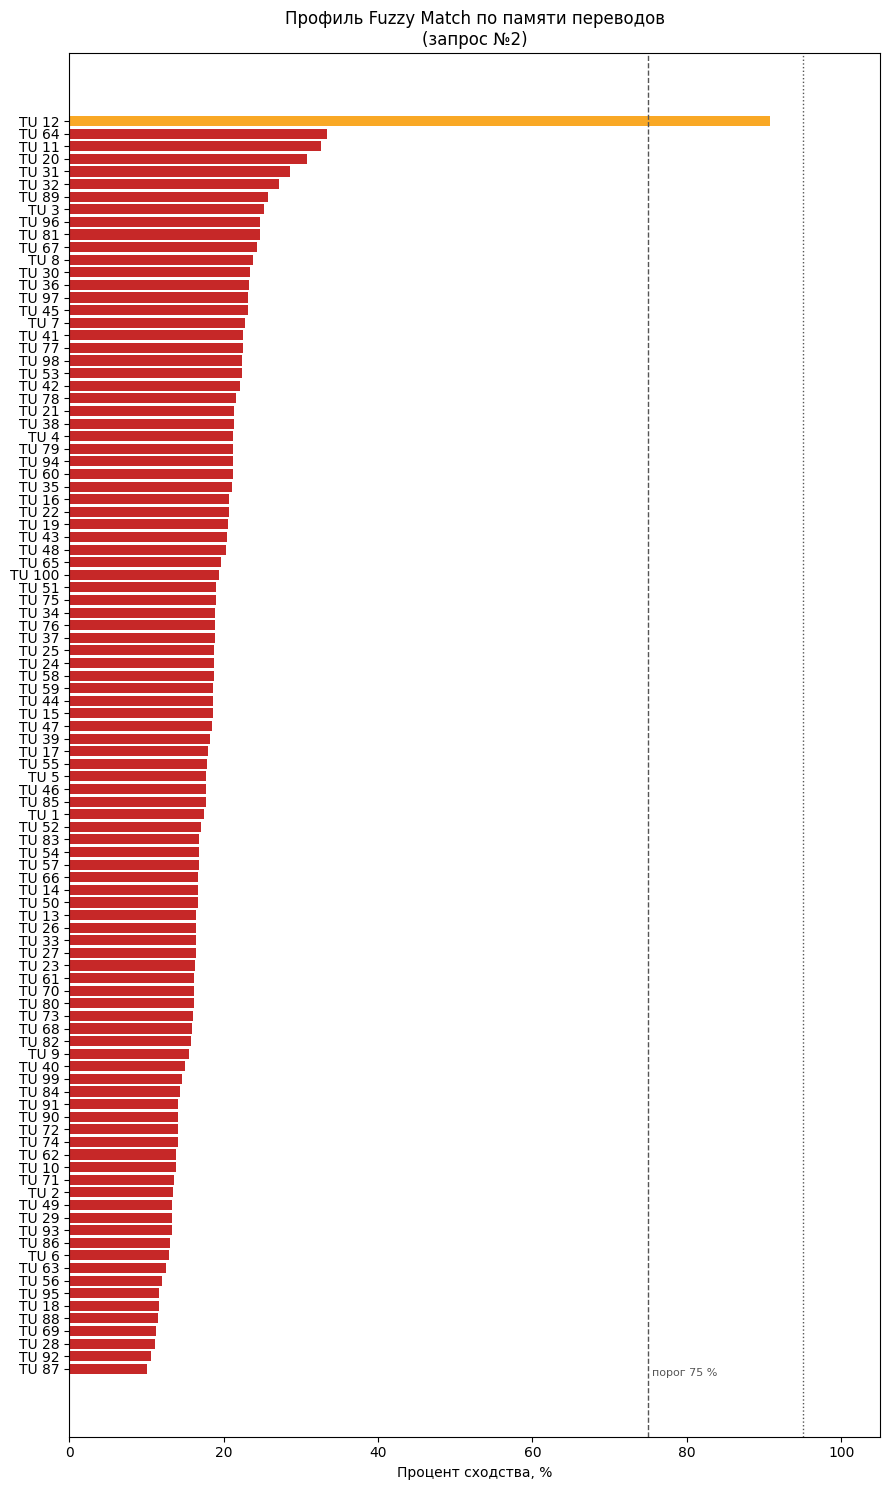

Максимум: 90.70 %   медиана: 18.13 %


In [ ]:
probe = QUERIES[1]["query"]
scores = [similarity(probe, seg)["score"] for seg in tm_df["source_segment"]]
profile = (pd.DataFrame({"tuid": tm_df["tuid"], "score": scores})
           .sort_values("score", ascending=True))

colors = ["#2e7d32" if value >= 95 else "#f9a825" if value >= 75 else "#c62828"
          for value in profile["score"]]

figure, axes = plt.subplots(figsize=(9, 15))
axes.barh([f"TU {tuid}" for tuid in profile["tuid"]], profile["score"], color=colors)
axes.axvline(75, color="#555555", linestyle="--", linewidth=1)
axes.axvline(95, color="#555555", linestyle=":", linewidth=1)
axes.set_xlim(0, 105)
axes.set_xlabel("Процент сходства, %")
axes.set_title("Профиль Fuzzy Match по памяти переводов\n(запрос №2)")
axes.text(75.5, -0.6, "порог 75 %", fontsize=8, color="#555555")
figure.tight_layout()
plt.show()

print(f"Максимум: {max(scores):.2f} %   медиана: {pd.Series(scores).median():.2f} %")

## Блок 7. Интеграция глоссария: подстановка терминов (2 балла)

Терминологическая разметка выполняется по правилам, принятым в CAT-системах:

* кандидаты сортируются по убыванию длины — многословный термин
  «uncrewed aircraft system» должен сработать раньше, чем «aircraft»;
* поиск регистронезависимый, но по границам слов, чтобы «pitot» не совпал
  внутри другого слова;
* уже размеченные фрагменты повторно не обрабатываются (защита от вложенных
  подстановок).

### Пояснение к блоку 7

**Что делает блок.** Ищет в исходном предложении известные термины и добавляет рядом их переводные эквиваленты из TBX-глоссария.

**Почему термины сортируются по длине.** Если сначала заменить короткий термин, он может разрушить более длинное словосочетание. Поэтому многословные единицы обрабатываются раньше.

**Почему используются границы слов.** Регулярное выражение `(?<!\w)...(?!\w)` предотвращает случайное совпадение термина как части другого слова.

**Зачем нужны временные маркеры `\x00...\x00`.** Уже выполненная подстановка временно защищается от повторной обработки. После завершения поиска маркеры заменяются на готовые фрагменты.

**Что показывает `glossary_coverage()`.** Функция не изменяет текст, а возвращает список найденных терминов. Это позволяет измерять терминологическое покрытие сегмента.

**Педагогический акцент.** Блок демонстрирует принцип контролируемой терминологии: автоматизация помогает не «переводить вместо человека», а снижать риск непоследовательного употребления специальных терминов.


In [ ]:
def apply_term_glossary(text: str, glossary_df: pd.DataFrame,
                        template: str = "{source} [{target}]") -> str:
    """Разметить исходный текст переводными эквивалентами из глоссария.

    Args:
        text: исходный сегмент на языке оригинала.
        glossary_df: таблица глоссария (результат :func:`parse_tbx`) с колонками
            ``source_term`` и ``target_term``.
        template: шаблон подстановки; поля ``{source}`` и ``{target}``.

    Returns:
        Текст, в котором найденные термины заменены по шаблону. Порядок слов и
        регистр исходного текста сохраняются.
    """
    if glossary_df.empty or not text:
        return text

    pairs = sorted(
        zip(glossary_df["source_term"], glossary_df["target_term"]),
        key=lambda pair: len(pair[0]), reverse=True,
    )

    protected: List[str] = []

    def _store(replacement: str) -> str:
        protected.append(replacement)
        return f"\x00{len(protected) - 1}\x00"

    result = text
    for source_term, target_term in pairs:
        pattern = re.compile(rf"(?<!\w){re.escape(source_term)}(?!\w)", re.IGNORECASE)
        result = pattern.sub(
            lambda match: _store(template.format(source=match.group(0), target=target_term)),
            result,
        )

    return re.sub(r"\x00(\d+)\x00", lambda m: protected[int(m.group(1))], result)


def glossary_coverage(text: str, glossary_df: pd.DataFrame) -> List[str]:
    """Вернуть список терминов глоссария, найденных в тексте."""
    found: List[str] = []
    for term in glossary_df["source_term"]:
        if re.search(rf"(?<!\w){re.escape(term)}(?!\w)", text, re.IGNORECASE):
            found.append(term)
    return found


DEMO_SEGMENTS = [
    "The electrocardiogram records the heart's electrical activation and the auscultation reveals a new murmur.",
    "In heart failure the reduced cardiac output and elevated preload produce pulmonary congestion.",
    "Atrial fibrillation increases the risk of thromboembolic stroke and requires anticoagulation.",
]

for segment in DEMO_SEGMENTS:
    print("-" * 100)
    print(f"Исходный сегмент : {segment}")
    print(f"С подстановкой   : {apply_term_glossary(segment, glossary_df)}")
    print(f"Найдено терминов : {len(glossary_coverage(segment, glossary_df))} "
          f"-> {glossary_coverage(segment, glossary_df)}")

----------------------------------------------------------------------------------------------------
Исходный сегмент : The electrocardiogram records the heart's electrical activation and the auscultation reveals a new murmur.
С подстановкой   : The electrocardiogram [электрокардиограмма] records the heart's electrical activation and the auscultation [аускультация] reveals a new murmur.
Найдено терминов : 2 -> ['auscultation', 'electrocardiogram']
----------------------------------------------------------------------------------------------------
Исходный сегмент : In heart failure the reduced cardiac output and elevated preload produce pulmonary congestion.
С подстановкой   : In heart failure [сердечная недостаточность] the reduced cardiac output [сердечный выброс] and elevated preload [преднагрузка] produce pulmonary congestion.
Найдено терминов : 3 -> ['heart failure', 'cardiac output', 'preload']
--------------------------------------------------------------------------------------

### 7.1. Симуляция работы переводчика: ТМ + глоссарий

Для каждого сегмента документа система сначала ищет совпадение в памяти
переводов; если процент ниже 75 %, сегмент передаётся переводчику с
предварительной терминологической разметкой.

### Пояснение к симуляции 7.1

---



Этот блок объединяет две ранее независимые технологии в единый рабочий процесс. Для каждого нового сегмента сначала выполняется поиск в TMX-памяти. Если найден подходящий кандидат, переводчику предлагается готовый или частично готовый перевод. Если совпадения нет, включается терминологическая подсказка из TBX.

Получается упрощённая модель поведения CAT-системы:

`новый сегмент → поиск в TM → оценка процента → предложение перевода или подсказка из глоссария`.

В таблице `pipeline_df` фиксируются тип совпадения, процент, предлагаемая подсказка и рекомендуемое действие. Это уже не отдельный алгоритм, а небольшой **конвейер поддержки принятия решения переводчиком**.

Для педагогической аудитории здесь полезно подчеркнуть идею человеко-машинного взаимодействия: система автоматизирует рутинный поиск и предлагает варианты, но окончательное решение остаётся за специалистом.


In [ ]:
DOCUMENT = [
    "Cardiovascular diseases (CVDs) are the most common cause of premature death in the world.",
    "Peripheral arterial disease is a circulatory problem in which narrowed arteries reduce blood flow to the limbs and causes symptoms of leg pain with walking.",
    "Infective endocarditis is an infection caused by bacteria that enter the bloodstream and cause inflammation in the heart tissues, often on a valve.",
]

pipeline_rows: List[Dict[str, Any]] = []
previous_segment: Optional[str] = "Exceeding the critical angle of attack leads to a stall."

for segment in DOCUMENT:
    matches = calculate_fuzzy_match(segment, tm_df, threshold=75.0,
                                    context_before=previous_segment, top_n=1)
    if matches:
        best = matches[0]
        action = "подставить из ТМ" if best["score"] >= 95 else "отредактировать вариант из ТМ"
        pipeline_rows.append({
            "segment": segment,
            "match_type": best["match_type"],
            "score": best["score"],
            "suggestion": best["target_segment"],
            "action": action,
        })
    else:
        pipeline_rows.append({
            "segment": segment,
            "match_type": "No Match",
            "score": 0.0,
            "suggestion": apply_term_glossary(segment, glossary_df),
            "action": "перевод с нуля по глоссарию",
        })
    previous_segment = segment

pipeline_df = pd.DataFrame(pipeline_rows)
for row in pipeline_rows:
    print("=" * 100)
    print(f"Сегмент    : {row['segment']}")
    print(f"Совпадение : {row['match_type']} ({row['score']:.2f} %) -> {row['action']}")
    print(f"Подсказка  : {row['suggestion']}")

print("=" * 100)
pipeline_df[["match_type", "score", "action"]]

Сегмент    : Cardiovascular diseases (CVDs) are the most common cause of premature death in the world.
Совпадение : Exact (100%) (100.00 %) -> подставить из ТМ
Подсказка  : Сердечно-сосудистые заболевания являются наиболее частой причиной преждевременной смерти в мире.
Сегмент    : Peripheral arterial disease is a circulatory problem in which narrowed arteries reduce blood flow to the limbs and causes symptoms of leg pain with walking.
Совпадение : Fuzzy (90.12 %) -> отредактировать вариант из ТМ
Подсказка  : Заболевание периферических артерий является нарушением кровообращения, при котором суженные артерии уменьшают кровоток в конечностях и вызывают боль в ногах при ходьбе (хромоту).
Сегмент    : Infective endocarditis is an infection caused by bacteria that enter the bloodstream and cause inflammation in the heart tissues, often on a valve.
Совпадение : Fuzzy (81.46 %) -> отредактировать вариант из ТМ
Подсказка  : Инфекционный эндокардит представляет собой инфекцию, вызванную бактери

,match_type,score,action
0,Exact (100%),100.00,подставить из ТМ
1,Fuzzy,90.12,отредактировать вариант из ТМ
2,Fuzzy,81.46,отредактировать вариант из ТМ


## Блок 8. Экспорт результатов для Smartcat

Smartcat импортирует глоссарии из CSV с заголовком вида
`Source (en);Target (ru);Comment` (UTF-8, разделитель — запятая или точка с
запятой). Память переводов загружается напрямую в формате `.tmx`.

Выгружаются три файла:

| Файл | Назначение |
|------|------------|
| `glossary_smartcat_v25.csv` | импорт глоссария в Smartcat |
| `tm_segments_v25.csv` | таблица параллельных сегментов для проверки |
| `fuzzy_report_v25.csv` | отчёт по найденным нечётким совпадениям |

### Пояснение к блоку 8

**Что делает блок.** Преобразует внутренние таблицы `pandas` в файлы, которые можно передать во внешнюю систему или использовать в отчёте.

**Почему используется CSV.** После сложной XML-обработки результат часто нужен в простой табличной форме. CSV хорошо подходит для обмена между Python, электронными таблицами и CAT-системами.

**Три вида экспорта имеют разные задачи.**
- `glossary_smartcat_v25.csv` — практический импорт терминов;
- `tm_segments_v25.csv` — контрольная таблица содержимого памяти переводов;
- `fuzzy_report_v25.csv` — аналитический отчёт о найденных совпадениях.

**Обратите внимание на `encoding="utf-8-sig"`.** Такая кодировка помогает корректно открывать русский текст в программах, которые ожидают BOM при чтении UTF-8.

**Результат блока.** Ноутбук не только выполняет вычисления, но и создаёт переносимые артефакты — важный этап любой прикладной работы с данными.


In [ ]:
GLOSSARY_CSV = "glossary_smartcat_v3.csv"
TM_CSV = "tm_segments_v3.csv"
FUZZY_CSV = "fuzzy_report_v3.csv"

smartcat_df = pd.DataFrame({
    "Source (en)": glossary_df["source_term"],
    "Target (ru)": glossary_df["target_term"],
    "Comment": glossary_df["definition"],
})
smartcat_df.to_csv(GLOSSARY_CSV, index=False, encoding="utf-8-sig",
                   quoting=csv.QUOTE_MINIMAL)

tm_df[["tuid", "source_segment", "target_segment", "domain"]].to_csv(
    TM_CSV, index=False, encoding="utf-8-sig")

matches_df[["query", "tuid", "source_segment", "target_segment",
            "score", "lev_ratio", "token_sort_ratio", "match_type"]].to_csv(
    FUZZY_CSV, index=False, encoding="utf-8-sig")

print("Экспортированные файлы:")
for name in [TBX_PATH, TMX_PATH, GLOSSARY_CSV, TM_CSV, FUZZY_CSV]:
    print(f"  {name:<28} {os.path.getsize(name):>7} байт")

print("\nПревью glossary_smartcat_v25.csv:")
smartcat_df.head(5)

Экспортированные файлы:
  variant_03.tbx                 81108 байт
  variant_03.tmx                 73082 байт
  glossary_smartcat_v25.csv      20234 байт
  tm_segments_v25.csv            52387 байт
  fuzzy_report_v25.csv             595 байт

Превью glossary_smartcat_v25.csv:


,Source (en),Target (ru),Comment
0,circulation of blood,кровообращение,The continuous movement of blood through t...
1,arterial pulse,артериальный пульс,The arterial pulse is the rhythmic expansi...
2,jugular venous pulse,яремный венозный пульс,The jugular venous pulse is a visible or p...
3,auscultation,аускультация,Auscultation is the clinical practice of l...
4,electrocardiogram,электрокардиограмма,The electrocardiogram records the heart’s ...


### 8.1. Итоговая сводка по работе

### Пояснение к итоговой сводке 8.1

Сводная таблица объединяет ключевые показатели лабораторной работы: корректность TBX, число единиц TMX, количество найденных Fuzzy Match, число ICE-совпадений и количество терминологических подстановок.

Это пример **автоматической самопроверки результата**. Вместо того чтобы оценивать работу только визуально, программа формирует измеримые показатели и статусы. Такой подход полезен и в учебных заданиях: критерии оценивания можно связывать с проверяемыми результатами выполнения программы.


In [ ]:
summary = pd.DataFrame([
    {"Этап": "1. Парсинг и валидация TBX", "Метрика": "термостатей",
     "Значение": report["entries"], "Статус": "OK" if report["valid"] else "ОШИБКА"},
    {"Этап": "2. Парсинг TMX", "Метрика": "единиц перевода",
     "Значение": len(tm_df), "Статус": "OK" if len(tm_df) >= 10 else "МАЛО ДАННЫХ"},
    {"Этап": "3. Fuzzy Match", "Метрика": "кандидатов выше порога",
     "Значение": len(matches_df), "Статус": "OK"},
    {"Этап": "3. ICE", "Метрика": "контекстных совпадений",
     "Значение": int((matches_df["match_type"] == "ICE (101%)").sum()), "Статус": "OK"},
    {"Этап": "4. Глоссарий", "Метрика": "терминов подставлено (демо)",
     "Значение": sum(len(glossary_coverage(s, glossary_df)) for s in DEMO_SEGMENTS),
     "Статус": "OK"},
])
print(summary.to_string(index=False))

                      Этап                     Метрика  Значение Статус
1. Парсинг и валидация TBX                 термостатей       100     OK
            2. Парсинг TMX             единиц перевода       100     OK
            3. Fuzzy Match      кандидатов выше порога         2     OK
                    3. ICE      контекстных совпадений         1     OK
              4. Глоссарий терминов подставлено (демо)         6     OK


## Выводы

1. Стандарт **TBX** (ISO 30042) описывает понятие как `termEntry` с одной
   `langSet` на язык; допускаются две формы записи термина — компактная `tig`
   и расширенная `ntig/termGrp`, поэтому надёжный парсер обязан обходить
   `langSet` целиком, а не рассчитывать на фиксированный путь.
2. Стандарт **TMX 1.4b** хранит выравненные сегменты как `tu → tuv → seg`;
   язык варианта задаётся атрибутом `xml:lang`, который в парсере раскрывается
   в полное имя с пространством имён XML.
3. Расстояние Левенштейна даёт базовую метрику Fuzzy Match, но чувствительно к
   перестановкам слов; комбинация с **Token Sort Ratio** повышает полноту
   выдачи без потери точности.
4. **ICE (In-Context Exact Match)** отличается от обычного 100 %-совпадения
   учётом соседних сегментов — только он позволяет подставлять перевод без
   проверки редактором.
5. Автоматическая терминологическая разметка требует сортировки терминов по
   убыванию длины и защиты уже размеченных фрагментов, иначе многословные
   термины разрушаются вложенными подстановками.

### Методический итог для преподавателя

Лабораторная работа связывает три уровня понимания:

1. **Форматы данных** — студент различает TBX, TMX и CSV и понимает их назначение.
2. **Алгоритмы обработки** — студент видит парсинг XML, нормализацию текста, расстояние Левенштейна, ранжирование и регулярные выражения.
3. **Прикладной сценарий** — отдельные алгоритмы объединяются в модель CAT-системы, где память переводов и терминологическая база совместно поддерживают работу переводчика.

Для педагогической аудитории особенно важно обсуждать не только программную реализацию, но и **дидактический смысл автоматизации**: какие действия пользователя снимает система, какие решения остаются за человеком, какие ошибки можно обнаружить автоматически и какие метрики позволяют оценить качество результата.
